# MALERIA DISEASE DYNAMICS

# **1. Data extaction**




1.1 Converting PDF into CSV

> The data required for this project was sourced from Data.gov.in, where three files were available in PDF format. Since PDF files are not suitable for direct data analysis, they were extracted and converted into CSV format. This conversion enabled the data to be structured in a tabular form, making it easier to clean, process, and analyze using various data analysis tools and techniques.


In [ ]:
pip install pdfplumber pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 22.7 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [ ]:
import pdfplumber
import pandas as pd
pdf_path = "Malaria-Annual-Report-2024.pdf"
all_tables = []
with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        tables = page.extract_tables()
        for table in tables:
            if not table or not table[0]: # Skip empty tables or tables with no header
                continue
            # Original headers are in table[0]
            original_headers = table[0]
            data_rows = table[1:]
            # Generate unique column names
            unique_headers = []
            counts = {}
            for header in original_headers:
                # Treat empty strings and None as a generic "Unnamed" column
                col_name = str(header).strip() if header is not None else ""
                if not col_name:
                    col_name = "Unnamed"
                if col_name in counts:
                    counts[col_name] += 1
                    unique_headers.append(f"{col_name}_{counts[col_name]}")
                else:
                    counts[col_name] = 0
                    unique_headers.append(col_name)
            if data_rows: # Ensure there are data rows to create a DataFrame
                df = pd.DataFrame(data_rows, columns=unique_headers)
                all_tables.append(df)
# Merge all tables
final_df = pd.concat(all_tables, ignore_index=True)
# Save to CSV
final_df.to_csv("malaria_report.csv", index=False)
print("CSV saved successfully!")

CSV saved successfully!


1.2 State and District Coordinate Extraction

> To support the subsequent stages of data extraction and analysis, the latitude and longitude coordinates corresponding to each state and district were required. Therefore, the relevant geographic data, including state names, district names, and their associated coordinates, was extracted and integrated with the dataset. This enabled accurate geospatial mapping, location-based analysis, and further data processing tasks.



In [ ]:
pip install pandas geopy tqdm

In [ ]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from tqdm import tqdm
import time
# Read file
df = pd.read_csv("/content/State_District.txt", sep="\t")
# Geocoder
geolocator = Nominatim(user_agent="india_district_locator")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
latitudes = []
longitudes = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    place = f"{row['District']}, {row['State']}, India"
    try:
        location = geocode(place)

        if location:
            latitudes.append(location.latitude)
            longitudes.append(location.longitude)
        else:
            latitudes.append(None)
            longitudes.append(None)
    except Exception:
        latitudes.append(None)
        longitudes.append(None)
df["Latitude"] = latitudes
df["Longitude"] = longitudes
df.to_csv("district_lat_long.csv", index=False)
print("Saved as district_lat_long.csv")

100%|██████████| 775/775 [12:57<00:00,  1.00s/it]

Saved as district_lat_long.csv


1.3 Environmental Data Extraction Using Google Earth Engine

> To enrich the district-level dataset with environmental and geospatial attributes, Google Earth Engine (GEE) was used to extract relevant data based on the latitude and longitude coordinates of each district. Using a 5 km buffer around each district location, environmental variables such as elevation, surface water occurrence, and Normalized Difference Vegetation Index (NDVI) were retrieved from publicly available satellite and geospatial datasets hosted on Google Earth Engine. Specifically, elevation data was obtained from the SRTM Digital Elevation Model (DEM), water occurrence information from the JRC Global Surface Water dataset, and vegetation data from the MODIS MOD13Q1 NDVI collection. The extracted values were then compiled and stored in a CSV file, creating a comprehensive environmental dataset for further analysis and modeling.



In [ ]:
import ee
import pandas as pd
from tqdm import tqdm
import time

# ------------------------------------------------------------------
# Initialize Earth Engine
# ------------------------------------------------------------------
ee.Authenticate()
ee.Initialize(project="neural-passkey-479712-k4")

# ------------------------------------------------------------------
# INPUT
# ------------------------------------------------------------------
INPUT_CSV = "district_lat_long.csv"
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BUFFER_RADIUS = 5000      # meters

# ------------------------------------------------------------------
# Read district coordinates
# ------------------------------------------------------------------
districts = pd.read_csv(INPUT_CSV)

# Ensure correct column names
districts.columns = districts.columns.str.strip()

# ------------------------------------------------------------------
# Earth Engine datasets
# ------------------------------------------------------------------

DEM = ee.Image("USGS/SRTMGL1_003")

WATER = (
    ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
    .select("occurrence")
)

NDVI_COLLECTION = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate(START_DATE, END_DATE)
    .select("NDVI")
)

# ------------------------------------------------------------------
# Helper
# ------------------------------------------------------------------

def get_geometry(lat, lon):
    return ee.Geometry.Point([lon, lat]).buffer(BUFFER_RADIUS)

# ------------------------------------------------------------------
# Process each district
# ------------------------------------------------------------------

results = []

for _, row in tqdm(districts.iterrows(), total=len(districts)):

    state = row["State"]
    district = row["District"]
    lat = float(row["Latitude"])
    lon = float(row["Longitude"])

    geom = get_geometry(lat, lon)

    try:

        # ---------------- Elevation ----------------

        elevation = DEM.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geom,
            scale=30,
            maxPixels=1e9
        ).get("elevation")

        elevation = ee.Number(elevation).getInfo()

        # ---------------- Water ----------------

        water = WATER.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geom,
            scale=30,
            maxPixels=1e9
        ).get("occurrence")

        water = ee.Number(water).getInfo()

        # ---------------- NDVI ----------------

        ndvi = NDVI_COLLECTION.mean().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geom,
            scale=250,
            maxPixels=1e9
        ).get("NDVI")

        ndvi = ee.Number(ndvi).getInfo()

        if ndvi is not None:
            ndvi = ndvi / 10000.0

        results.append({
            "State": state,
            "District": district,
            "Latitude": lat,
            "Longitude": lon,
            "Elevation_m": elevation,
            "Water_Occurrence_pct": water,
            "NDVI_2024": ndvi
        })

    except Exception as e:

        print(f"Error : {district} -> {e}")

        results.append({
            "State": state,
            "District": district,
            "Latitude": lat,
            "Longitude": lon,
            "Elevation_m": None,
            "Water_Occurrence_pct": None,
            "NDVI_2024": None
        })

    # Prevent API overload
    time.sleep(0.2)

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

output = pd.DataFrame(results)
output.to_csv("district_environment_2024.csv", index=False)
print(output.head())
print(f"\nSaved {len(output)} districts.")

100%|██████████| 773/773 [09:52<00:00,  1.31it/s]

            State          District   Latitude  Longitude  Elevation_m  \
0  Andhra Pradesh  Alluri Sitharama  18.059196  82.674901  1063.917544   
1  Andhra Pradesh        Anakapalli  17.671533  82.774757   137.774384   
2  Andhra Pradesh     Ananthapuramu  14.012699  78.418022   449.402336   
3  Andhra Pradesh         Annamayya  13.788358  78.634629   606.527591   
4  Andhra Pradesh           Bapatla  15.934430  80.450552     4.820400   

   Water_Occurrence_pct  NDVI_2024  
0             25.023810   0.617818  
1             42.813834   0.673155  
2             40.431404   0.417714  
3             17.929516   0.446772  
4             35.989780   0.478397  

Saved 773 districts.


# **2. Data Cleaning**



Socio-Economic Data Cleaning and Transformation

- Loaded the raw socio-economic dataset from the source file.
- Filtered and retained only the indicators relevant to malaria analysis.
- Validated the presence of all required indicators and identified any missing entries.
- Removed unnecessary variables to focus on key socio-economic factors.
- Transformed the dataset structure by converting indicator rows into columns.
- Reshaped the data into a state-level tabular format for easier analysis.
- Standardized and renamed column headers using consistent naming conventions.
- Organized the cleaned data into a tidy format suitable for merging with other datasets.
- Exported the final processed dataset as `socioeconomic_tidy.csv`.
- Prepared the dataset for subsequent integration with malaria and environmental data.






In [ ]:
import pandas as pd

# ---------------------------------------------------------------------------
# 1. Loading raw socio-economic file
# ---------------------------------------------------------------------------
raw = pd.read_csv("socioeconomic_raw.csv")   # or pd.read_excel("...xlsx")

# ---------------------------------------------------------------------------
# 2. Keep only the indicators relevant to malaria
#    Edit this list to match the EXACT indicator text in your file
# ---------------------------------------------------------------------------
KEEP_INDICATORS = [
    "Per Capita NSDP at 2004-05 prices (Rs.)",
    "Population Density (Per Sq. Km.)",
    "Total Literacy Rate (%)",
    "Infant Mortality Rate (IMR) (per 1000 live births)",
    "Household availing banking services",
    "Households with latrine facility within premises",
    "Safe Drinking Water (Tap/Handpump/Tubewell) (%age)",
    "Forest Cover (% of geographical area)",
    "Rural Tele Density (%)",
]

filtered = raw[raw[INDICATOR_COL].isin(KEEP_INDICATORS)].copy()

missing = set(KEEP_INDICATORS) - set(filtered[INDICATOR_COL])
if missing:
    print("WARNING - these indicators were not found in the file (check exact spelling):")
    for m in missing:
        print("  -", m)

# ---------------------------------------------------------------------------
# 3. Transpose: indicators (rows) -> columns, states (columns) -> rows
# ---------------------------------------------------------------------------
tidy = filtered.set_index(INDICATOR_COL)[STATE_ORDER].transpose()
tidy.index.name = "state"
tidy = tidy.reset_index()

# clean up column names (snake_case, shorter)
rename_map = {
    "Per Capita NSDP at 2004-05 prices (Rs.)": "per_capita_nsdp_rank",
    "Population Density (Per Sq. Km.)": "population_density_rank",
    "Total Literacy Rate (%)": "literacy_rate_rank",
    "Infant Mortality Rate (IMR) (per 1000 live births)": "imr_rank",
    "Household availing banking services": "banking_access_rank",
    "Households with latrine facility within premises": "latrine_facility_rank",
    "Safe Drinking Water (Tap/Handpump/Tubewell) (%age)": "safe_water_rank",
    "Forest Cover (% of geographical area)": "forest_cover_rank",
    "Rural Tele Density (%)": "rural_tele_density_rank",
}
tidy = tidy.rename(columns=rename_map)

# ---------------------------------------------------------------------------
# 4. Save - ready to merge with your malaria panel on 'state'
# ---------------------------------------------------------------------------
tidy.to_csv("socioeconomic_tidy.csv", index=False)
print(f"Saved socioeconomic_tidy.csv - {len(tidy)} states x {len(tidy.columns)-1} indicators")
print(tidy.head())

Saved socioeconomic_tidy.csv - 29 states x 9 indicators
Indicator              state  per_capita_nsdp_rank  population_density_rank  \
0             Andhra Pradesh                  13.0                     16.0   
1          Arunachal Pradesh                  17.0                     29.0   
2                      Assam                  26.0                     10.0   
3                      Bihar                  29.0                      2.0   
4               Chhattisgarh                  22.0                     20.0   

Indicator  literacy_rate_rank  imr_rank  rural_tele_density_rank  \
0                        25.0      20.0                     12.0   
1                        28.0      13.0                     13.0   
2                        20.0      28.0                     25.0   
3                        29.0      22.0                     28.0   
4                        21.0      23.0                     26.0   

Indicator  banking_access_rank  latrine_facility_rank  safe_

### Malaria Data Cleaning and Feature Engineering

- Loaded the state-wise malaria surveillance dataset for the period 2022-2026.
- Standardized state names by removing extra spaces and applying consistent formatting.
- Identified and flagged partial-year records (e.g., "2026 up to June") to distinguish them from complete annual observations.
- Extracted and converted year values into a consistent numerical format for analysis.
- Cleaned numeric fields by removing commas, spaces, and invalid entries before converting them to numeric data types.
- Performed data quality checks to identify inconsistencies such as positive cases exceeding tested samples and *Plasmodium falciparum* cases exceeding total positive cases.
- Removed duplicate state-year records to ensure dataset integrity.
- Generated key epidemiological indicators, including:
  - Slide Positivity Rate (SPR)
  - *P. falciparum* Percentage (PF%)
  - Case Fatality Rate (CFR)
  - Testing Intensity Index
- Sorted records chronologically to support time-series analysis.
- Created lag features to capture previous year's malaria burden for each state.
- Calculated year-over-year percentage changes in positive malaria cases to identify trends.
- Generated rolling average features to smooth annual fluctuations and highlight long-term patterns.
- Merged engineered features back into the main dataset.
- Exported the final processed dataset as `malaria_statewise_cleaned.csv`.
- Prepared the dataset for trend analysis, predictive modeling, and integration with environmental and socio-economic datasets.

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("malaria_statewise_2022_2026.csv")

# ---------------------------------------------------------------------------
# 1. CLEANING
# ---------------------------------------------------------------------------

# 1a. Standardize state names (match casing/whitespace used elsewhere)
df["state"] = df["state"].str.strip().str.title()

# 1b. Handle the partial year "2026(upto June)"
#     Keep it as its own flag rather than dropping it - it's still useful
#     for very recent trend context, just not comparable to full years.
df["is_partial_year"] = df["year"].astype(str).str.contains(r"\(", regex=True)
df["year_clean"] = df["year"].astype(str).str.extract(r"(\d{4})").astype(int)

# 1c. Make sure numeric columns are actually numeric (commas, stray spaces, etc.)
numeric_cols = ["blood_slides_tested", "positive_cases", "pf_cases", "deaths"]
for col in numeric_cols:
    df[col] = (
        df[col].astype(str)
               .str.replace(",", "", regex=False)
               .str.strip()
               .replace("", np.nan)
               .astype(float)
    )

# 1d. Sanity checks - flag impossible rows (positive > tested, pf > positive)
df["flag_positive_gt_tested"] = df["positive_cases"] > df["blood_slides_tested"]
df["flag_pf_gt_positive"] = df["pf_cases"] > df["positive_cases"]
n_flagged = df[["flag_positive_gt_tested","flag_pf_gt_positive"]].any(axis=1).sum()
print(f"Flagged {n_flagged} rows with internal inconsistencies - inspect before modeling")

# 1e. Drop exact duplicate rows if any
before = len(df)
df = df.drop_duplicates(subset=["state", "year"])
print(f"Dropped {before - len(df)} duplicate state-year rows")

# ---------------------------------------------------------------------------
# 2. FEATURE ENGINEERING
# ---------------------------------------------------------------------------

# 2a. Rates - the most important derived features
df["slide_positivity_rate"] = df["positive_cases"] / df["blood_slides_tested"] * 100   # SPR
df["pf_percentage"] = df["pf_cases"] / df["positive_cases"].replace(0, np.nan) * 100    # PF%
df["case_fatality_rate"] = df["deaths"] / df["positive_cases"].replace(0, np.nan) * 100 # CFR
df["testing_intensity"] = df["blood_slides_tested"] / df["blood_slides_tested"].groupby(df["state"]).transform("mean")
# testing_intensity > 1 means this state-year tested more than that state's own average
# (useful to check if a case spike is real or a testing-effort artifact)

# 2b. Sort before creating lag/trend features
df = df.sort_values(["state", "year_clean"])

# 2c. Lag features (year-over-year), computed only across FULL years
full_years = df[~df["is_partial_year"]].copy()
full_years["positive_cases_lag1"] = full_years.groupby("state")["positive_cases"].shift(1)
full_years["cases_yoy_change_pct"] = (
    (full_years["positive_cases"] - full_years["positive_cases_lag1"])
    / full_years["positive_cases_lag1"] * 100
)

# 2d. Rolling average (smooths year-to-year noise, only 3 full years available
#     here so a 2-year rolling window is more realistic than 3)
full_years["positive_cases_roll2"] = (
    full_years.groupby("state")["positive_cases"]
              .transform(lambda x: x.shift(1).rolling(2).mean())
)

# merge lag/rolling features back onto the full df (partial year rows get NaN)
df = df.merge(
    full_years[["state","year_clean","positive_cases_lag1","cases_yoy_change_pct","positive_cases_roll2"]],
    on=["state","year_clean"], how="left"
)

# ---------------------------------------------------------------------------
# 3. SAVE
# ---------------------------------------------------------------------------
df.to_csv("malaria_statewise_cleaned.csv", index=False)
print(f"Saved malaria_statewise_cleaned.csv - {len(df)} rows, {df['state'].nunique()} states")
print(df.head(10))

Flagged 0 rows with internal inconsistencies - inspect before modeling
Dropped 0 duplicate state-year rows
Saved malaria_statewise_cleaned.csv - 180 rows, 36 states
                         state             year  blood_slides_tested  \
0  Andaman And Nicobar Islands             2022              31737.0   
1  Andaman And Nicobar Islands             2023              38986.0   
2  Andaman And Nicobar Islands             2024              47413.0   
3  Andaman And Nicobar Islands             2025              55701.0   
4  Andaman And Nicobar Islands  2026(upto June)              25722.0   
5               Andhra Pradesh             2022            8653048.0   
6               Andhra Pradesh             2023           10294202.0   
7               Andhra Pradesh             2024           12364281.0   
8               Andhra Pradesh             2025           12898436.0   
9               Andhra Pradesh  2026(upto June)            6457045.0   

   positive_cases  pf_cases  deaths  is_pa

### District-Level Malaria Data Cleaning and Feature Engineering

#### Data Cleaning

- Loaded the district-wise malaria surveillance dataset covering the years 2000-2024.
- Standardized state and district names by removing extra whitespace and applying consistent formatting.
- Converted case and mortality variables into numeric data types to ensure analytical accuracy.
- Identified records with unknown state information and flagged them for validation.
- Used a district-to-state lookup table to infer and populate missing state names wherever possible.
- Generated audit flags to track original unknown states, successfully matched records, and unresolved entries.
- Saved unresolved state records separately for manual review and quality assurance.
- Excluded records with unresolved state information from the modeling dataset.
- Standardized district name variants and historical naming inconsistencies to ensure uniformity across years.
- Aggregated duplicate district-year records created during district name standardization.
- Performed validation checks to identify records where reported deaths exceeded reported malaria cases.
- Sorted the dataset by state, district, and year to prepare it for temporal analysis.

#### Feature Engineering

- Calculated **Case Fatality Rate (CFR)** to measure mortality among reported malaria cases.
- Generated one-year, two-year, and three-year lag features to capture historical disease burden.
- Computed three-year and five-year rolling averages to smooth annual fluctuations in malaria incidence.
- Calculated year-over-year percentage changes in reported cases to identify growth and decline patterns.
- Derived five-year volatility measures to assess variability in malaria transmission over time.
- Created district-level trend indicators using rolling linear regression slopes to quantify long-term disease trends.
- Generated historical baseline features representing the average malaria burden observed in prior years.
- Ranked districts within each state and year based on malaria case counts to support hotspot identification and comparative analysis.
- Added data confidence indicators to distinguish years with higher uncertainty resulting from source reconstruction and interpolation processes.

#### Output

- Exported the cleaned and enriched dataset as `malaria_district_wise_cleaned.csv`.
- Generated a separate audit file, `malaria_district_wise_unknown_state_audit.csv`, containing records with unresolved state information.
- Produced an analysis-ready district-level malaria dataset suitable for hotspot detection, trend analysis, forecasting, and integration with environmental and socio-economic datasets.

In [ ]:
df = pd.read_csv("malaria_district_wise_2000_2024.csv")

# ---------------------------------------------------------------------------
# 1. CLEANING
# ---------------------------------------------------------------------------

# 1a. Standardize text fields
for col in ["state", "district"]:
    df[col] = df[col].str.strip().str.title()

# 1b. Numeric type safety
for col in ["total_cases", "total_deaths"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 1c. Handle UNKNOWN states - keep a flag, don't silently drop
# ---------------------------------------------------------------------------
# 1c. Fill UNKNOWN states using state_district.csv
# ---------------------------------------------------------------------------

# Read lookup table
lookup = pd.read_csv("/content/district_lat_long.csv")

lookup["State"] = lookup["State"].str.strip().str.title()
lookup["District"] = lookup["District"].str.strip().str.title()

# Remove duplicate district mappings (keep first if multiple)
lookup = lookup.drop_duplicates(subset="District")

# Create dictionary: district -> state
district_to_state = dict(zip(lookup["District"], lookup["State"]))

# Flag original unknowns
df["state_is_unknown_original"] = df["state"].eq("Unknown")

# Fill unknown states
mask = df["state"].eq("Unknown")

df.loc[mask, "state"] = (
    df.loc[mask, "district"]
      .map(district_to_state)
      .fillna("Unknown")
)

# Flag rows that are STILL unknown
df["state_is_unknown"] = df["state"].eq("Unknown")

print(f"Originally unknown : {df['state_is_unknown_original'].sum()}")
print(f"Matched from lookup: {(df['state_is_unknown_original'] & ~df['state_is_unknown']).sum()}")
print(f"Still unknown      : {df['state_is_unknown'].sum()}")

# Save remaining unknowns for manual inspection
df_unknown = df[df["state_is_unknown"]].copy()

# Keep only rows with known state for modelling
df = df[~df["state_is_unknown"]].copy()
# 1d. Standardize known district name variants (extend this dict as you find more)
DISTRICT_RENAME = {
    "East Nimar": "Khandwa", "West Nimar": "Khandwa (West Nimar)",
    "Ahmadabad": "Ahmedabad", "Ananthapuramu": "Anantapur",
    "Bara Banki": "Barabanki", "Cooch Behar": "Coochbehar",
    "Nagpur Mc#": "Nagpur", "Pune Mc#": "Pune",
    "Osmanabad": "Dharashiv", "Nellore": "Spsr Nellore",
    # add more as you find fragmentation during EDA - check with:
    # df.groupby("district")["state"].nunique().sort_values(ascending=False)
}
df["district"] = df["district"].replace(DISTRICT_RENAME)

# 1e. Duplicate check - same district-year appearing twice (can happen from
#     district splits/renames colliding after standardization above)
dupes = df[df.duplicated(subset=["state","district","year"], keep=False)]
if len(dupes):
    print(f"WARNING: {len(dupes)} duplicate district-year rows after renaming - "
          "likely two old district names collapsing into one. Aggregating (sum).")
    df = (df.groupby(["state","district","year"], as_index=False)
            .agg(total_cases=("total_cases","sum"), total_deaths=("total_deaths","sum")))

# 1f. Flag implausible rows
df["flag_deaths_gt_cases"] = df["total_deaths"] > df["total_cases"]
print(f"{df['flag_deaths_gt_cases'].sum()} rows have deaths > cases - inspect these")

# 1g. Sort - required before any lag/rolling feature
df = df.sort_values(["state", "district", "year"]).reset_index(drop=True)

# ---------------------------------------------------------------------------
# 2. FEATURE ENGINEERING
# ---------------------------------------------------------------------------

# 2a. Case fatality rate
df["case_fatality_rate"] = df["total_deaths"] / df["total_cases"].replace(0, np.nan) * 100

# 2b. Lag features (previous year's cases) - core input for forecasting
group = df.groupby(["state","district"])
df["cases_lag1"] = group["total_cases"].shift(1)
df["cases_lag2"] = group["total_cases"].shift(2)
df["cases_lag3"] = group["total_cases"].shift(3)

# 2c. Rolling averages (smooth out year-to-year noise / reporting variation)
df["cases_roll3"] = group["total_cases"].transform(lambda x: x.shift(1).rolling(3).mean())
df["cases_roll5"] = group["total_cases"].transform(lambda x: x.shift(1).rolling(5).mean())

# 2d. Year-over-year change and volatility
df["cases_yoy_change_pct"] = (df["total_cases"] - df["cases_lag1"]) / df["cases_lag1"].replace(0, np.nan) * 100
df["cases_volatility_5yr"] = group["total_cases"].transform(lambda x: x.shift(1).rolling(5).std())

# 2e. District-level trend feature - long-run linear trend direction/strength
#     (slope of cases over all prior years available at each point)
def rolling_trend(series):
    slopes = [np.nan]  # first year has no prior data
    for i in range(1, len(series)):
        y = series.iloc[:i].values
        if len(y) < 3 or np.all(np.isnan(y)):
            slopes.append(np.nan)
            continue
        x = np.arange(len(y))
        mask = ~np.isnan(y)
        if mask.sum() < 3:
            slopes.append(np.nan)
            continue
        slope = np.polyfit(x[mask], y[mask], 1)[0]
        slopes.append(slope)
    return pd.Series(slopes, index=series.index)

df["cases_trend_slope"] = group["total_cases"].transform(rolling_trend)

# 2f. District's historical baseline (mean cases across all prior years -
#     captures "is this a historically high-burden district")
df["cases_historical_mean"] = group["total_cases"].transform(lambda x: x.shift(1).expanding().mean())

# 2g. Rank each district within its state-year (relative burden, useful for
#     hotspot analysis / choropleth prep)
df["rank_within_state_year"] = df.groupby(["state","year"])["total_cases"].rank(ascending=False)

# 2h. Time-block flag for years affected by interpolation uncertainty
#     (from how the source PDF's merged-cell years were reconstructed -
#     boundary years carry more risk of being off by one year)
df["year_confidence"] = np.where(df["year"].isin([2000, 2024]), "lower", "normal")

# ---------------------------------------------------------------------------
# 3. SAVE
# ---------------------------------------------------------------------------
df.to_csv("malaria_district_wise_cleaned.csv", index=False)
df_unknown.to_csv("malaria_district_wise_unknown_state_audit.csv", index=False)

print(f"\nSaved malaria_district_wise_cleaned.csv - {len(df)} rows, "
      f"{df['district'].nunique()} unique districts, {df['year'].nunique()} years")
print(df.head(10))

Originally unknown : 1423
Matched from lookup: 299
Still unknown      : 1124
0 rows have deaths > cases - inspect these

Saved malaria_district_wise_cleaned.csv - 14994 rows, 707 unique districts, 25 years
                         state district  year  total_cases  total_deaths  \
0  Andaman And Nicobar Islands  Andaman  2000         1021             1   
1  Andaman And Nicobar Islands  Andaman  2001          388             1   
2  Andaman And Nicobar Islands  Andaman  2002          326             0   
3  Andaman And Nicobar Islands  Andaman  2003          305             0   
4  Andaman And Nicobar Islands  Andaman  2004          720             0   
5  Andaman And Nicobar Islands  Andaman  2005         1119             0   
6  Andaman And Nicobar Islands  Andaman  2006          175             0   
7  Andaman And Nicobar Islands  Andaman  2007          302             0   
8  Andaman And Nicobar Islands  Andaman  2008          201             0   
9  Andaman And Nicobar Islands  An

# **3. Exploaratory data analytics**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

In [ ]:
cases = pd.read_csv("malaria_district_wise_cleaned.csv")
env = pd.read_csv("district_environment_2024.csv")
state_cases = pd.read_csv("malaria_statewise_cleaned.csv")
socio = pd.read_csv("socioeconomic_tidy.csv")

# Rename columns in env for consistency with cases dataframe
env = env.rename(columns={'District': 'district', 'State': 'state'})

for df_, col_name in [(cases, "state"), (cases, "district"), (env, "state"), (env, "district"),
                  (state_cases, "state"), (socio, "state")]:
    if col_name in df_.columns:
        df_[col_name] = df_[col_name].astype(str).str.strip().str.title()

# district panel = cases + environment (env is static, no year -> merge on district only)
district_panel = cases.merge(env, on="district", how="left", suffixes=("", "_env"))

# state panel = state cases + socioeconomic (static, merge on state only)
state_panel = state_cases.merge(socio, on="state", how="left")

print(f"District panel: {len(district_panel)} rows, {district_panel['district'].nunique()} districts")
print(f"State panel: {len(state_panel)} rows, {state_panel['state'].nunique()} states")

District panel: 15069 rows, 707 districts
State panel: 180 rows, 36 states


DESCRIPTIVE STATISTICS

In [ ]:

print("\n=== District-level case statistics ===")
print(district_panel["total_cases"].describe())
print(f"Skewness: {district_panel['total_cases'].skew():.2f}")   # expect high positive skew

print("\n=== State-level positivity statistics ===")
print(state_panel[["blood_slides_tested","positive_cases","slide_positivity_rate"]].describe())

# save a clean summary stats table for the report
summary_stats = district_panel.groupby("state")["total_cases"].agg(
    ["sum","mean","median","std","max"]).sort_values("sum", ascending=False)
summary_stats.to_csv("report_table_state_summary_stats.csv")



=== District-level case statistics ===
count    15069.000000
mean      1394.083814
std       4133.097810
min          0.000000
25%         11.000000
50%        137.000000
75%        885.000000
max      96693.000000
Name: total_cases, dtype: float64
Skewness: 7.10

=== State-level positivity statistics ===
       blood_slides_tested  positive_cases  slide_positivity_rate
count         1.800000e+02      180.000000             180.000000
mean          4.327133e+06     5351.200000               0.865296
std           5.722251e+06    11259.875593               7.481613
min           2.000000e+00        0.000000               0.000000
25%           1.567300e+05       42.750000               0.009188
50%           8.140080e+05      370.000000               0.040531
75%           7.330993e+06     3868.250000               0.203317
max           3.161965e+07    68693.000000             100.000000


TEMPORAL ANALYSIS

In [ ]:
national = district_panel.groupby("year")["total_cases"].sum().reset_index()
plt.figure()
plt.plot(national["year"], national["total_cases"], marker="o", color="#c0392b")
plt.title("National Malaria Trend, 2000-2024")
plt.xlabel("Year"); plt.ylabel("Total Cases")
plt.tight_layout(); plt.savefig("chart_01_national_trend.png", dpi=150); plt.close()

# Pre/post major policy period comparison (India's NVBDCP intensified after ~2015-16
# with the National Framework for Malaria Elimination, launched 2016)
national["period"] = np.where(national["year"] < 2016, "Pre-2016", "2016 onward")
period_stats = national.groupby("period")["total_cases"].agg(["mean","std"])
print("\n=== Pre/Post-2016 national case comparison ===")
print(period_stats)

t_stat, p_val = stats.ttest_ind(
    national[national["period"]=="Pre-2016"]["total_cases"],
    national[national["period"]=="2016 onward"]["total_cases"]
)
print(f"t-test pre vs post 2016: t={t_stat:.2f}, p={p_val:.4f}")

plt.figure()
sns.boxplot(data=national, x="period", y="total_cases")
plt.title("National Cases: Pre-2016 vs 2016 Onward\n(National Framework for Malaria Elimination launched 2016)")
plt.tight_layout(); plt.savefig("chart_02_pre_post_2016.png", dpi=150); plt.close()



=== Pre/Post-2016 national case comparison ===
                     mean            std
period                                  
2016 onward  3.445249e+05  311340.230626
Pre-2016     1.119170e+06  190379.015528
t-test pre vs post 2016: t=7.76, p=0.0000


SPATIAL / HOTSPOT ANALYSIS

In [ ]:
top20 = (district_panel.groupby(["state","district"])["total_cases"]
         .mean().sort_values(ascending=False).head(20).reset_index())
top20["label"] = top20["district"] + " (" + top20["state"] + ")"
plt.figure(figsize=(9,8))
sns.barplot(data=top20, y="label", x="total_cases", color="#8e44ad")
plt.title("Top 20 Districts by Mean Annual Cases (2000-2024)")
plt.tight_layout(); plt.savefig("chart_03_top_districts.png", dpi=150); plt.close()

DRIVER CORRELATION ANALYSIS

In [ ]:
driver_cols = [c for c in ["total_cases","Elevation_m","Water_Occurrence_pct","NDVI_2024"]
               if c in district_panel.columns]
if len(driver_cols) > 2:
    corr = district_panel[driver_cols].corr()
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
    plt.title("Correlation - District Cases vs Environmental Drivers")
    plt.tight_layout(); plt.savefig("chart_04_driver_correlation.png", dpi=150); plt.close()

socio_rank_cols = [c for c in state_panel.columns if c.endswith("_rank")]
if socio_rank_cols:
    corr2 = state_panel[["positive_cases"] + socio_rank_cols].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr2[["positive_cases"]].sort_values("positive_cases"),
                annot=True, fmt=".2f", cmap="RdBu_r", center=0)
    plt.title("Correlation - State Cases vs Socioeconomic Rank Indicators\n(lower rank = better, check sign carefully)")
    plt.tight_layout(); plt.savefig("chart_05_socioeconomic_correlation.png", dpi=150); plt.close()

 GOVERNMENT ACTION INSIGHT


*   Classify each district by its long-run trend direction/magnitude.
*  Declining districts = plausible sign of successful intervention.
*  Rising/flat-high districts = plausible sign that action is still needed.

In [ ]:
def trend_slope(group):
    g = group.dropna(subset=["total_cases"]).sort_values("year")
    if len(g) < 5:
        return np.nan
    x = g["year"].values
    y = g["total_cases"].values
    slope = np.polyfit(x, y, 1)[0]
    return slope

trend_by_district = (
    district_panel.groupby(["state","district"])
    .apply(lambda g: pd.Series({
        "trend_slope": trend_slope(g),
        "mean_cases": g["total_cases"].mean(),
        "recent_3yr_mean": g[g["year"]>=2022]["total_cases"].mean(),
        "early_3yr_mean": g[g["year"]<=2002]["total_cases"].mean(),
    }))
    .reset_index()
)
trend_by_district["pct_change_early_to_recent"] = (
    (trend_by_district["recent_3yr_mean"] - trend_by_district["early_3yr_mean"])
    / trend_by_district["early_3yr_mean"].replace(0, np.nan) * 100
)

# Districts with strong decline = "action appears to be working"
improved = trend_by_district[
    (trend_by_district["mean_cases"] > trend_by_district["mean_cases"].median()) &
    (trend_by_district["pct_change_early_to_recent"] < -50)
].sort_values("pct_change_early_to_recent").head(15)

# Districts still high AND not improving = "action still needed"
needs_action = trend_by_district[
    (trend_by_district["recent_3yr_mean"] > trend_by_district["recent_3yr_mean"].quantile(0.9)) &
    (trend_by_district["pct_change_early_to_recent"] > -20)
].sort_values("recent_3yr_mean", ascending=False).head(15)

improved.to_csv("report_table_districts_improved.csv", index=False)
needs_action.to_csv("report_table_districts_needs_action.csv", index=False)

print("\n=== Districts showing strongest improvement (>50% decline, high baseline burden) ===")
print(improved[["state","district","early_3yr_mean","recent_3yr_mean","pct_change_early_to_recent"]].to_string(index=False))

print("\n=== Districts still high-burden with limited improvement (action likely still needed) ===")
print(needs_action[["state","district","recent_3yr_mean","pct_change_early_to_recent"]].to_string(index=False))

plt.figure(figsize=(9,6))
plot_df = pd.concat([
    improved.assign(group="Improved (declining)"),
    needs_action.assign(group="Still high burden")
])
sns.barplot(data=plot_df, y="district", x="recent_3yr_mean", hue="group")
plt.title("Districts: Recent Burden - Improved vs Still-High-Burden Groups")
plt.xlabel("Mean Cases, 2022-2024"); plt.ylabel("")
plt.tight_layout(); plt.savefig("chart_06_action_needed_vs_improved.png", dpi=150); plt.close()

/tmp/ipykernel_999/1437568171.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({



=== Districts showing strongest improvement (>50% decline, high baseline burden) ===
            state        district  early_3yr_mean  recent_3yr_mean  pct_change_early_to_recent
Arunachal Pradesh Upper Subansiri      540.000000         0.000000                 -100.000000
            Assam   Karbi Anglong    13504.000000         0.000000                 -100.000000
          Haryana            Jind       47.666667         0.000000                 -100.000000
          Haryana         Kaithal        1.000000         0.000000                 -100.000000
        Karnataka A.M.U. Almatti#     1284.666667         0.000000                 -100.000000
        Rajasthan  Sawai Madhopur     2086.666667         0.000000                 -100.000000
   Madhya Pradesh       Tikamgarh     1545.666667         0.000000                 -100.000000
Arunachal Pradesh     East Kameng     1976.666667         0.000000                 -100.000000
   Andhra Pradesh   West Godavari      390.666667         0

Find pairs of districts with SIMILAR environmental conditions

In [ ]:
env_features = [c for c in ["Elevation_m","Water_Occurrence_pct","NDVI_2024"] if c in district_panel.columns]

if len(env_features) >= 2:
    d = district_panel.groupby(["state","district"])[env_features + ["total_cases"]].mean().dropna().reset_index()

    # normalize environmental features so distance is comparable across scales
    d_norm = d.copy()
    for c in env_features:
        d_norm[c] = (d[c] - d[c].mean()) / d[c].std()

    from scipy.spatial.distance import pdist, squareform
    dist_matrix = squareform(pdist(d_norm[env_features].values))

    # for each district, find its nearest environmental neighbor
    np.fill_diagonal(dist_matrix, np.inf)
    nearest_idx = dist_matrix.argmin(axis=1)
    nearest_dist = dist_matrix.min(axis=1)

    d["nearest_neighbor_district"] = d["district"].values[nearest_idx]
    d["nearest_neighbor_state"] = d["state"].values[nearest_idx]
    d["env_distance"] = nearest_dist
    d["neighbor_cases"] = d["total_cases"].values[nearest_idx]
    d["case_ratio"] = d["total_cases"] / d["neighbor_cases"].replace(0, np.nan)

    # keep only genuinely similar pairs (small environmental distance)
    # but with a large case-rate gap - these are the interesting cases
    close_pairs = d[d["env_distance"] < d["env_distance"].quantile(0.2)].copy()
    close_pairs["case_gap_ratio"] = close_pairs[["case_ratio"]].apply(
        lambda r: max(r["case_ratio"], 1/r["case_ratio"]) if r["case_ratio"] not in [0, np.inf] and not pd.isna(r["case_ratio"]) else np.nan,
        axis=1
    )
    interesting_pairs = close_pairs.sort_values("case_gap_ratio", ascending=False).head(15)
    interesting_pairs.to_csv("report_table_similar_condition_different_outcome.csv", index=False)

    print("\n=== Districts with SIMILAR environment but VERY DIFFERENT case rates ===")
    print("(same environmental conditions, different burden -> points to non-environmental drivers)")
    print(interesting_pairs[["state","district","total_cases","nearest_neighbor_state",
                              "nearest_neighbor_district","neighbor_cases","case_gap_ratio"]].to_string(index=False))

    # visualize one clear example pair
    if len(interesting_pairs) > 0:
        example = interesting_pairs.iloc[0]
        ex_districts = [example["district"], example["nearest_neighbor_district"]]
        ex_data = district_panel[district_panel["district"].isin(ex_districts)]
        plt.figure()
        sns.lineplot(data=ex_data, x="year", y="total_cases", hue="district", marker="o")
        plt.title(f"Case Study: Similar Environment, Different Outcomes\n"
                  f"{example['district']} vs {example['nearest_neighbor_district']}")
        plt.tight_layout(); plt.savefig("chart_07_matched_pair_example.png", dpi=150); plt.close()


=== Districts with SIMILAR environment but VERY DIFFERENT case rates ===
(same environmental conditions, different burden -> points to non-environmental drivers)
         state   district  total_cases nearest_neighbor_state nearest_neighbor_district  neighbor_cases  case_gap_ratio
     Rajasthan   Bhilwara  2162.200000              Telangana                Narayanpet        0.833333     2594.640000
     Telangana Narayanpet     0.833333              Rajasthan                  Bhilwara     2162.200000     2594.640000
         Bihar    Sheohar     0.400000          Uttar Pradesh                 Chandauli      327.040000      817.600000
 Uttar Pradesh  Chandauli   327.040000                  Bihar                   Sheohar        0.400000      817.600000
     Telangana  Vikarabad     3.875000         Madhya Pradesh                     Seoni     2418.280000      624.072258
Madhya Pradesh      Seoni  2418.280000              Telangana                 Vikarabad        3.875000      624.0722

IDEAL CONDITION PROFILING
*  Compare the environmental/socioeconomic profile of consistently
*   LOW-burden vs consistently HIGH-burden districts/states.

/tmp/ipykernel_999/3167116925.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile_summary = profile.groupby("burden_group")[env_features].mean() if env_features else None



=== Environmental profile by burden group (mean values) ===
              Elevation_m  Water_Occurrence_pct  NDVI_2024
burden_group                                              
Low burden     623.844007             31.820983   0.518357
Mid            352.386134             30.678750   0.490628
High burden    332.264531             36.062028   0.485302
Confirmed: Chart saved successfully to /content/chart_08_ideal_condition_profile.png

=== All charts and report tables saved ===


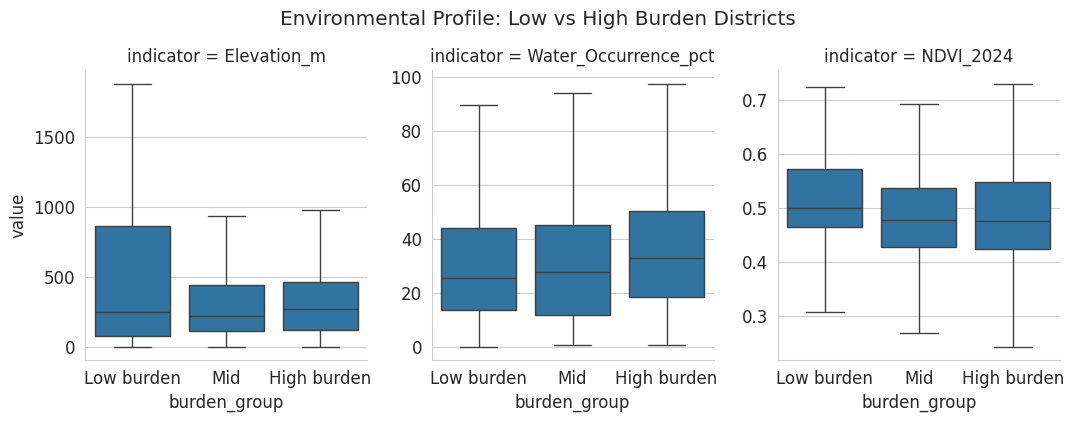

In [ ]:
import os

district_burden = district_panel.groupby(["state","district"])["total_cases"].mean().reset_index()
district_burden["burden_group"] = pd.qcut(district_burden["total_cases"], 3,
                                            labels=["Low burden","Mid","High burden"])

profile = district_burden.merge(env, on="district", how="left")
profile_summary = profile.groupby("burden_group")[env_features].mean() if env_features else None
if profile_summary is not None:
    print("\n=== Environmental profile by burden group (mean values) ===")
    print(profile_summary)
    profile_summary.to_csv("report_table_ideal_condition_profile.csv")

    profile_long = profile.melt(id_vars="burden_group", value_vars=env_features,
                                  var_name="indicator", value_name="value")
    g = sns.catplot(data=profile_long, x="burden_group", y="value", col="indicator",
                     kind="box", sharey=False, height=4, aspect=0.9, showfliers=False)
    g.fig.suptitle("Environmental Profile: Low vs High Burden Districts", y=1.05)
    chart_filepath = "/content/chart_08_ideal_condition_profile.png"
    g.savefig(chart_filepath, dpi=150)

    if os.path.exists(chart_filepath):
        print(f"Confirmed: Chart saved successfully to {chart_filepath}")
    else:
        print(f"WARNING: Chart was *not* found after saving attempt at {chart_filepath}")

print("\n=== All charts and report tables saved ===")

Display of all charts

Displaying chart_01_national_trend.png:


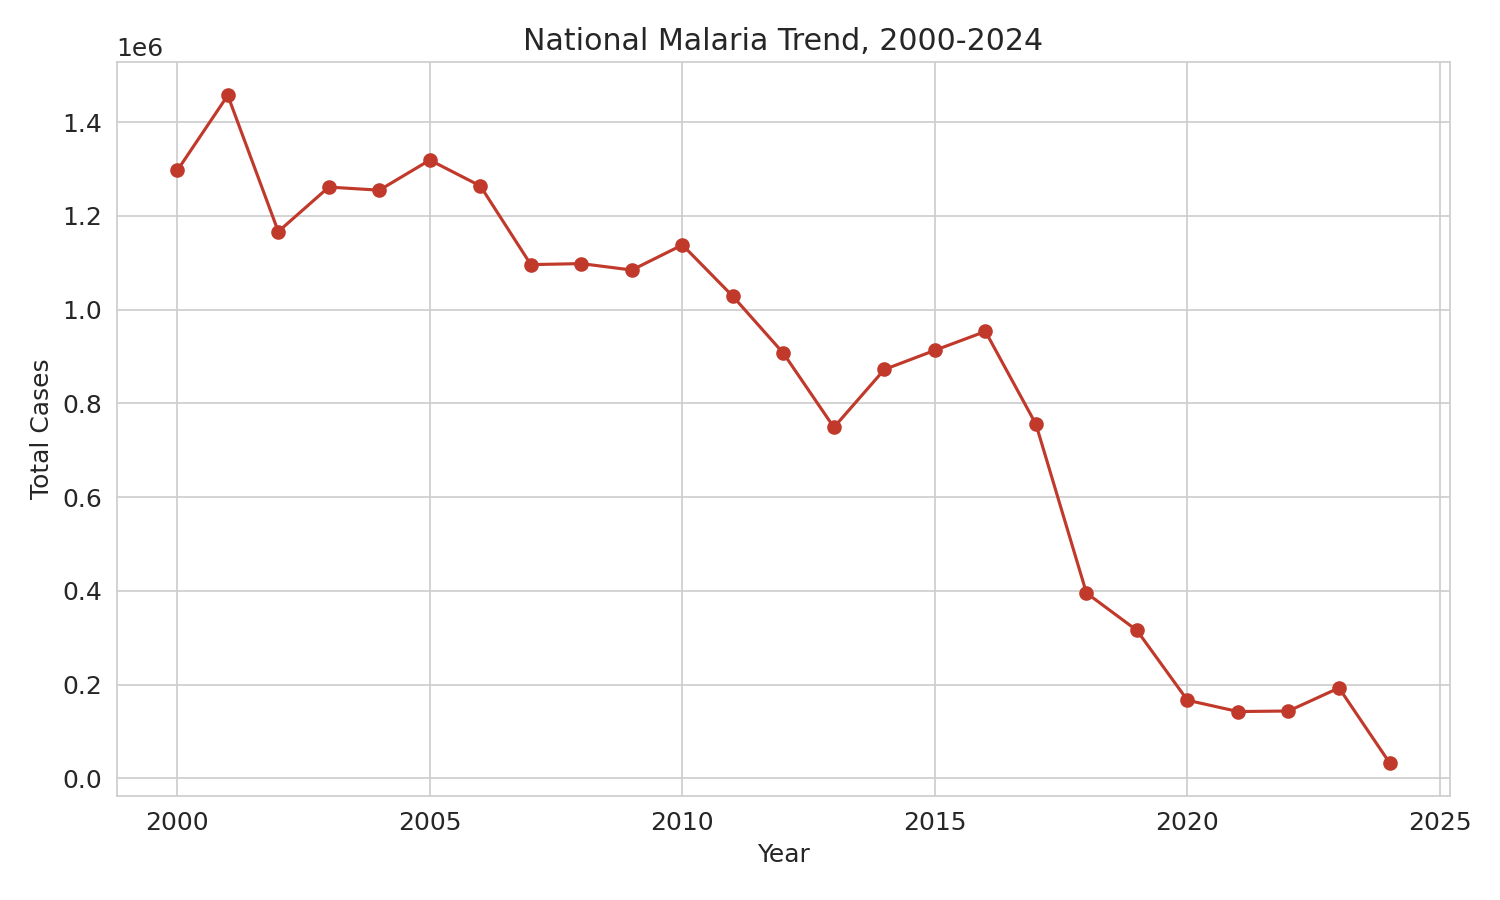

Displaying chart_02_pre_post_2016.png:


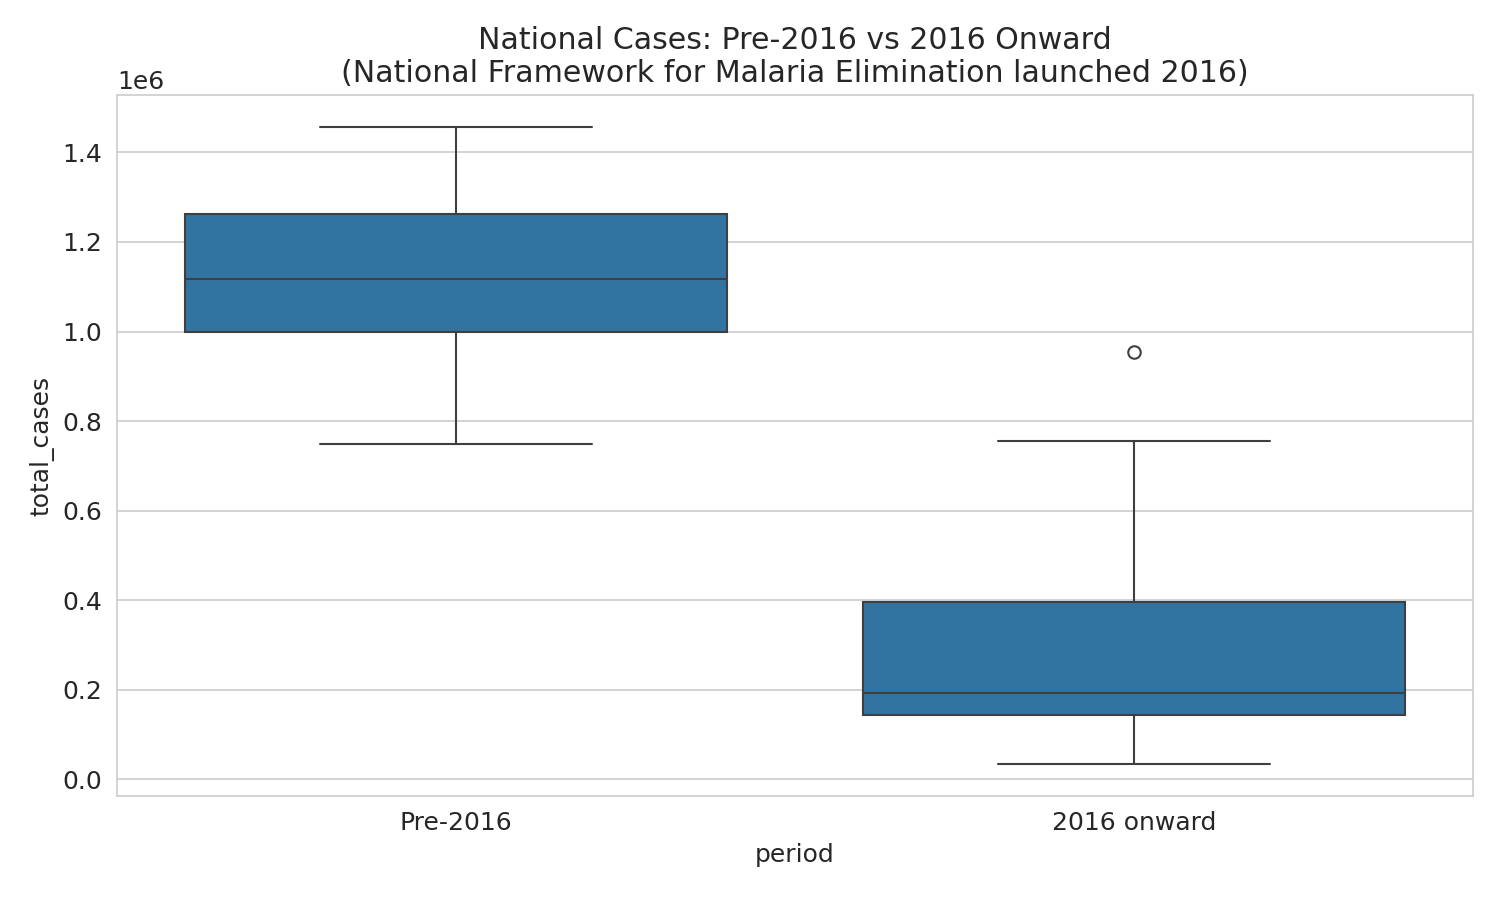

Displaying chart_03_top_districts.png:


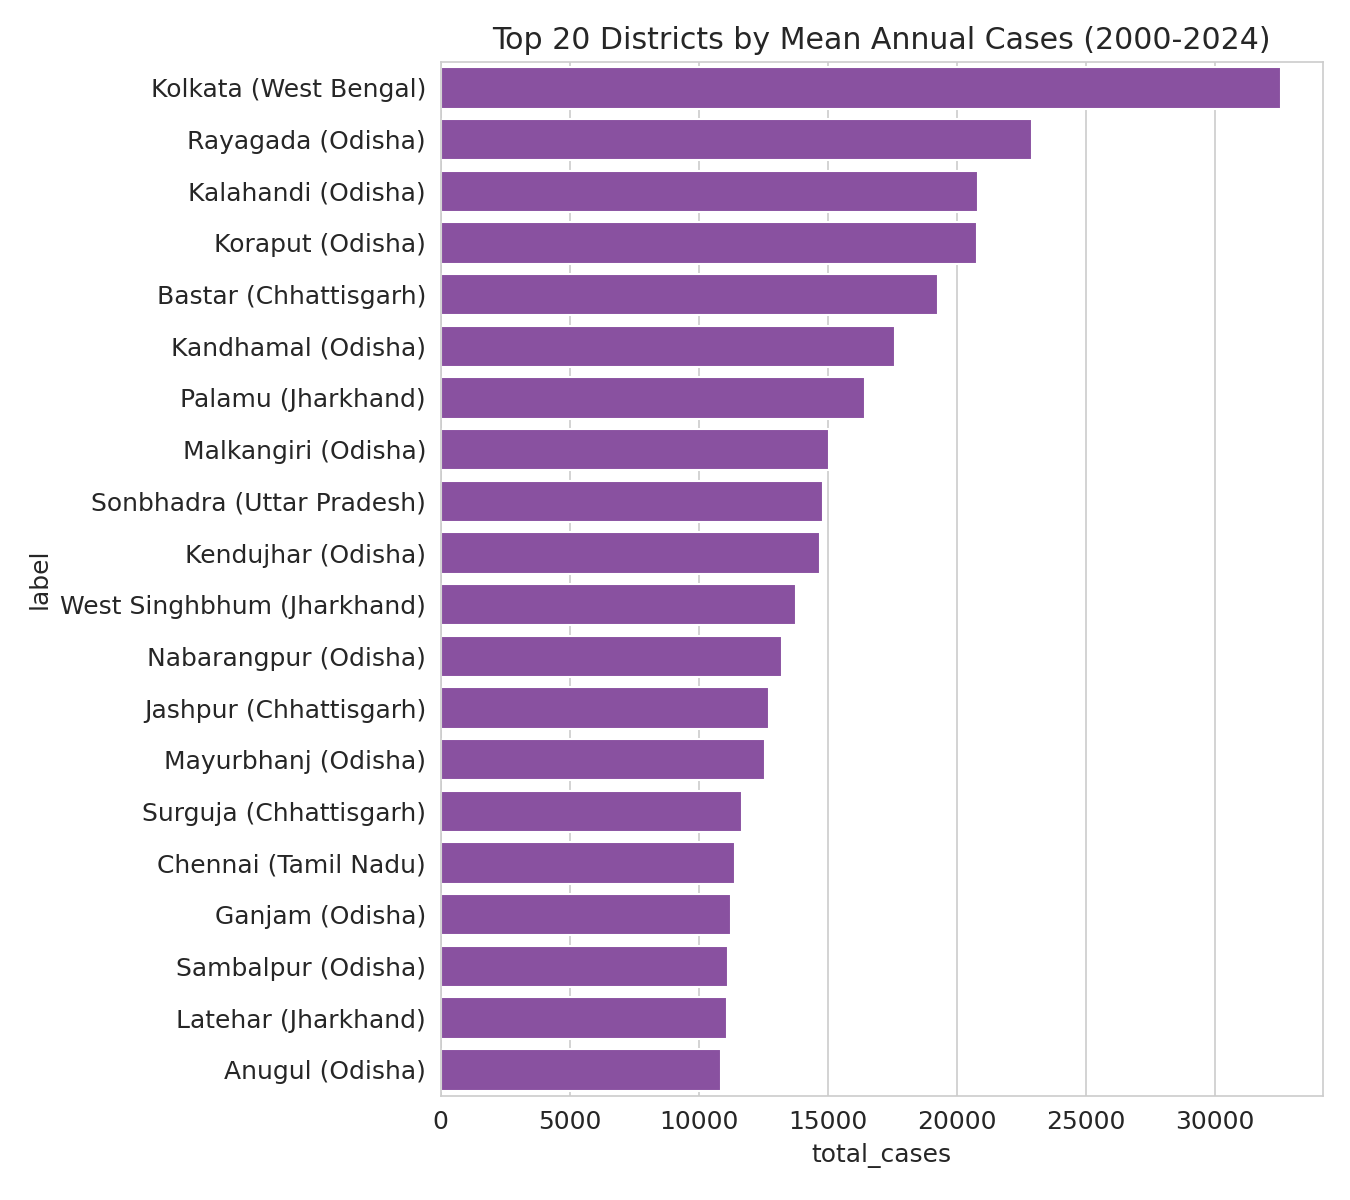

Displaying chart_04_driver_correlation.png:


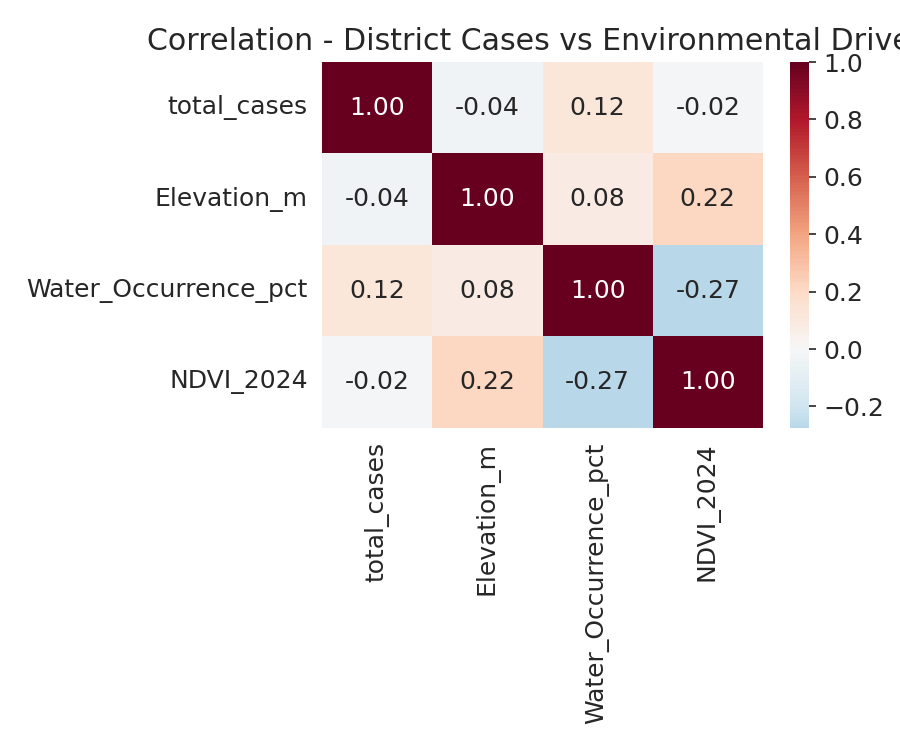

Displaying chart_05_socioeconomic_correlation.png:


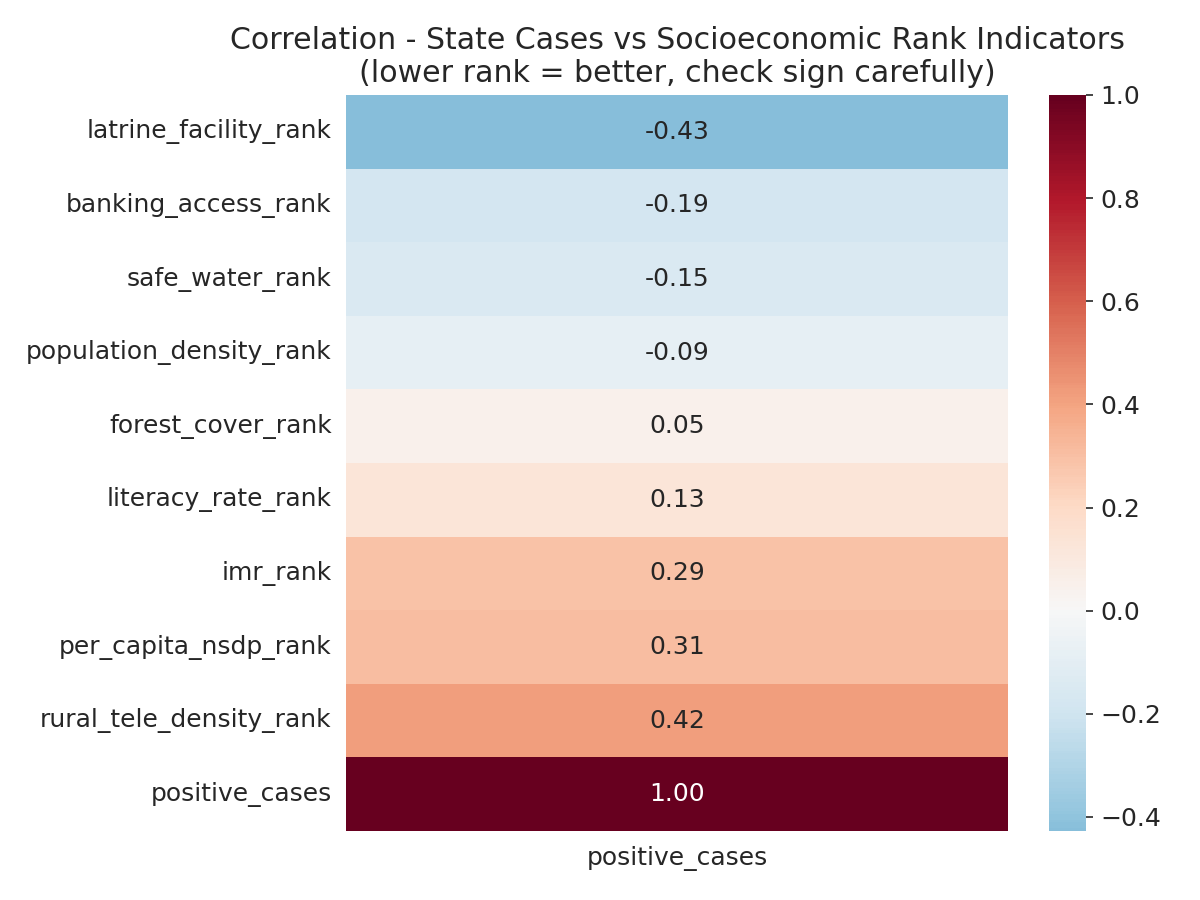

Displaying chart_06_action_needed_vs_improved.png:


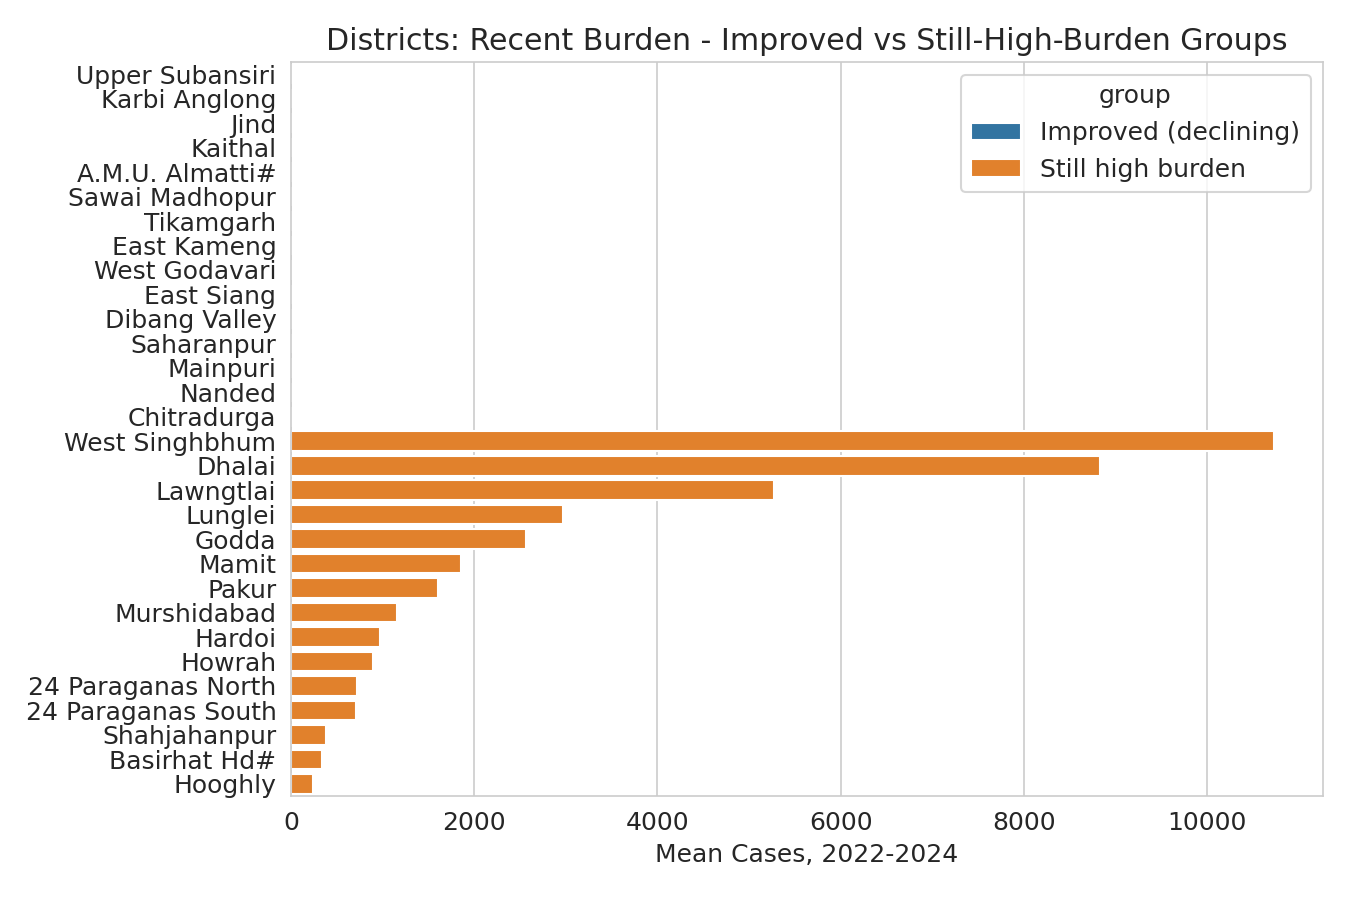

Displaying chart_07_matched_pair_example.png:


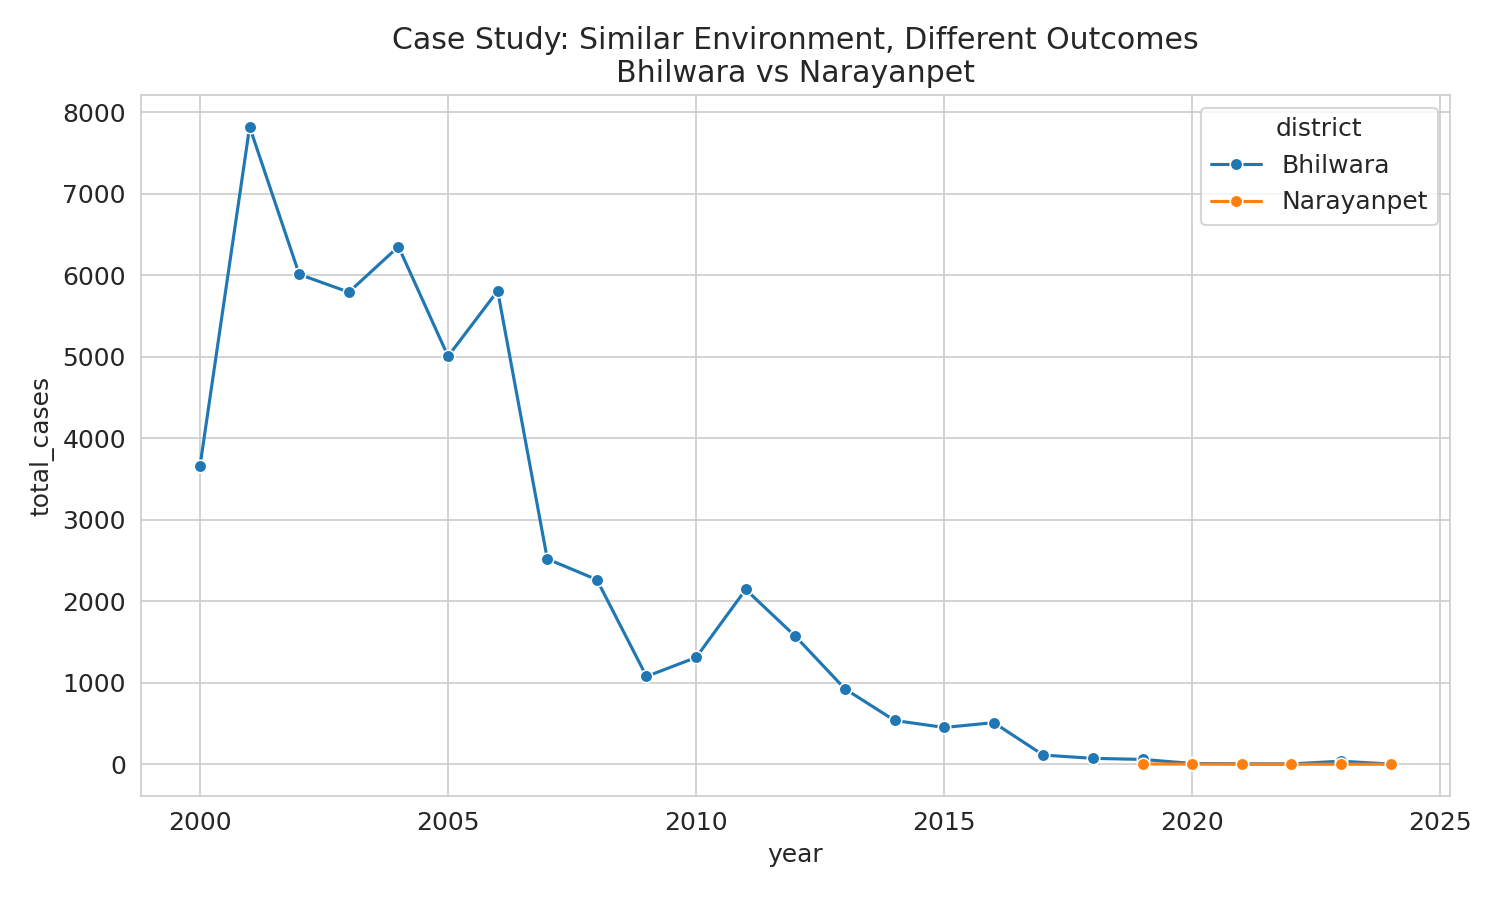

Displaying chart_08_ideal_condition_profile.png:


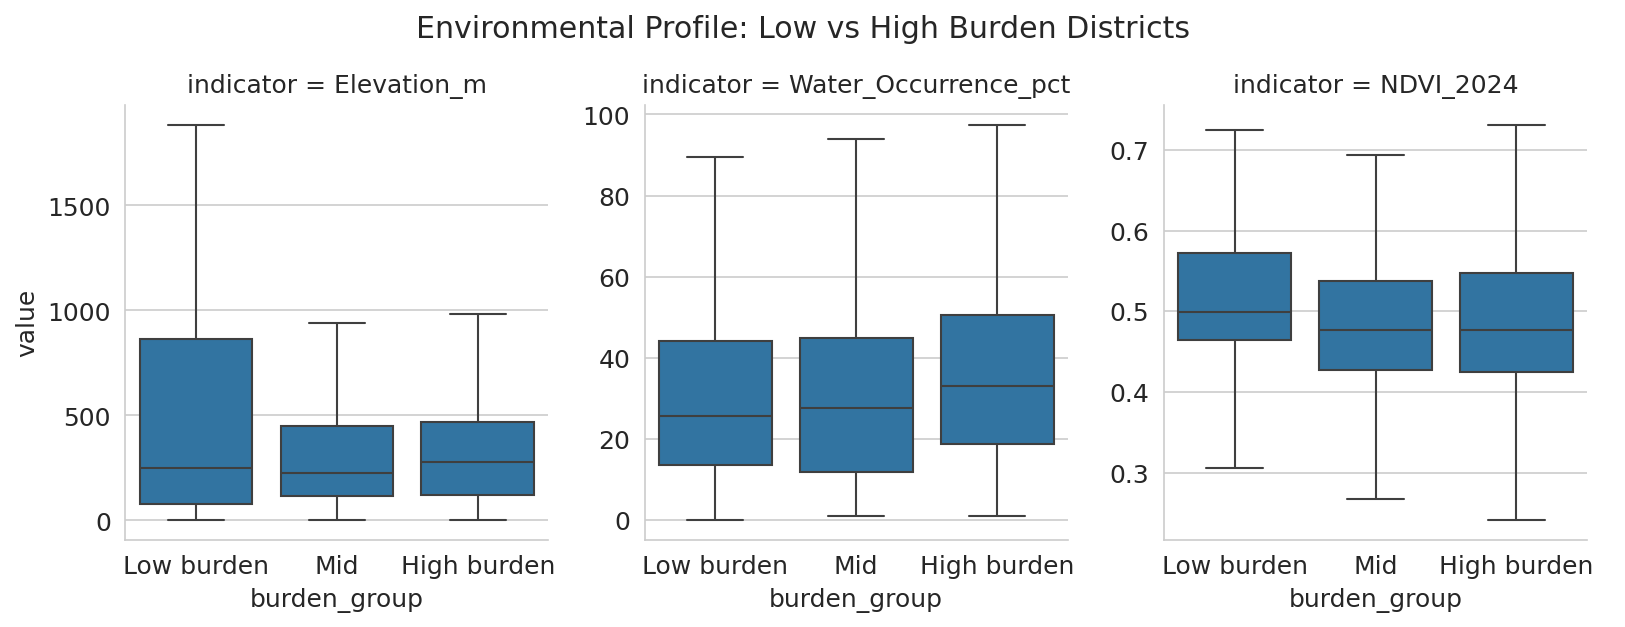

In [ ]:
from IPython.display import Image, display

# List of chart filenames generated in previous steps
chart_files = [
    "chart_01_national_trend.png",
    "chart_02_pre_post_2016.png",
    "chart_03_top_districts.png",
    "chart_04_driver_correlation.png",
    "chart_05_socioeconomic_correlation.png",
    "chart_06_action_needed_vs_improved.png",
    "chart_07_matched_pair_example.png",
    "chart_08_ideal_condition_profile.png"
]

for chart_file in chart_files:
    print(f"Displaying {chart_file}:")
    display(Image(filename=chart_file))


# **4. Model training & Analysis**

### District-Level Malaria Forecasting Using Gradient Boosting

#### Model Development

- Selected district-level malaria case counts (`total_cases`) as the target variable for prediction.
- Built a predictive model using the **Gradient Boosting Regressor**, an ensemble machine learning algorithm capable of capturing complex non-linear relationships.
- Utilized historical malaria burden indicators, temporal trends, and environmental variables as input features.
- Included lag-based features representing malaria cases from the previous one, two, and three years.
- Incorporated rolling averages, historical means, trend slopes, and volatility measures to capture long-term disease patterns.
- Integrated environmental factors such as elevation, water occurrence, vegetation index (NDVI), and derived environmental risk indicators.
- Excluded features with potential target leakage to ensure realistic model performance and generalizability.

#### Training and Evaluation

- Applied a temporal train-test split to preserve real-world forecasting conditions.
- Used data up to **2023** for model training and **2024** data for testing.
- Applied a logarithmic transformation (`log1p`) to malaria case counts to reduce skewness and improve model stability.
- Generated predictions and transformed results back to the original scale for interpretation.
- Created a baseline forecasting model using the previous year's malaria cases (naive approach) for comparison.

#### Performance Assessment

- Evaluated model performance using:
  - **Mean Absolute Error (MAE)**
  - **Root Mean Squared Error (RMSE)**
  - **Mean Absolute Percentage Error (MAPE)**
- Compared Gradient Boosting predictions against the naive baseline model to assess forecasting improvement.
- Analyzed feature importance scores to identify the most influential predictors of malaria incidence.

#### Output Generation

- Generated district-level malaria case predictions for the test period.
- Calculated prediction residuals to measure forecasting errors.
- Exported model predictions to `district_model_predictions.csv`.
- Saved feature importance rankings in `district_model_feature_importance.csv`.
- Stored model evaluation metrics in `district_model_metrics.csv`.
- Produced outputs that can be used for malaria hotspot identification, risk assessment, and future forecasting analyses.

In [4]:

import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("malaria_district_wise_cleaned.csv")  # or your merged panel with env features

TARGET = "total_cases"

FEATURES = [
    "cases_lag1", "cases_lag2", "cases_lag3",
    "cases_roll3", "cases_roll5",
    "cases_trend_slope", "cases_historical_mean", "cases_volatility_5yr",
    "elevation_m", "water_occurrence_pct", "ndvi_2024",
    "high_water_area", "high_ndvi",
    # NOT included: rank_within_state_year, cases_per_1000m_elevation (leakage risk)
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"District model features: {FEATURES}")

TRAIN_END_YEAR = 2023
TEST_START_YEAR = 2024

model_df = df.dropna(subset=FEATURES + [TARGET]).copy()
print(f"{len(model_df)} usable rows (of {len(df)} total)")

train = model_df[model_df["year"] <= TRAIN_END_YEAR]
test = model_df[model_df["year"] >= TEST_START_YEAR]
print(f"Train: {len(train)} rows ({train['year'].min()}-{train['year'].max()})")
print(f"Test:  {len(test)} rows ({test['year'].min()}-{test['year'].max()})")

# log1p transform - case counts are right-skewed, this stabilizes training.
# We evaluate metrics back on the ORIGINAL scale (expm1) so MAE/RMSE stay interpretable.
y_train_log = np.log1p(train[TARGET])
y_test = test[TARGET]

model = GradientBoostingRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42
)
model.fit(train[FEATURES], y_train_log)

pred_log = model.predict(test[FEATURES])
pred = np.expm1(pred_log)
pred = np.clip(pred, 0, None)

naive_pred = test["cases_lag1"]

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])).mean() * 100
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE_pct": mape}

results = [
    evaluate(y_test.values, pred, "District GradientBoosting"),
    evaluate(y_test.values, naive_pred.values, "District Naive (last year)"),
]
metrics_df = pd.DataFrame(results)
print("\nDistrict model performance:")
print(metrics_df.to_string(index=False))

importance_df = pd.DataFrame({
    "feature": FEATURES, "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

# Save predictions - needed later for the combination model
out = test[["state", "district", "year", TARGET]].copy()
out["predicted"] = pred
out["naive_predicted"] = naive_pred.values
out["residual"] = out[TARGET] - out["predicted"]
out.to_csv("district_model_predictions.csv", index=False)
importance_df.to_csv("district_model_feature_importance.csv", index=False)
metrics_df.to_csv("district_model_metrics.csv", index=False)

print("\nSaved: district_model_predictions.csv, district_model_feature_importance.csv, district_model_metrics.csv")

District model features: ['cases_lag1', 'cases_lag2', 'cases_lag3', 'cases_roll3', 'cases_roll5', 'cases_trend_slope', 'cases_historical_mean', 'cases_volatility_5yr']
11557 usable rows (of 14994 total)
Train: 10907 rows (2005-2023)
Test:  650 rows (2024-2024)

District model performance:
                     model        MAE        RMSE    MAPE_pct
 District GradientBoosting 183.776037  941.239027  983.396888
District Naive (last year) 260.466154 1294.673701 1429.874686

Saved: district_model_predictions.csv, district_model_feature_importance.csv, district_model_metrics.csv


### State-Level Malaria Forecasting Using Gradient Boosting

#### Model Development

- Developed a state-level malaria forecasting model to predict annual positive malaria cases.
- Selected only non-leaking features to ensure realistic prediction performance and avoid information derived directly from the target variable.
- Utilized historical malaria burden indicators, testing intensity measures, and socio-economic variables as predictor features.
- Incorporated lag-based and rolling-average features to capture temporal disease patterns and historical trends.
- Included socio-economic indicators such as income, population density, literacy rate, infant mortality rate, sanitation access, banking services, drinking water availability, forest cover, and rural tele-density.

#### Model Training Strategy

- Excluded partial-year observations to maintain consistency in annual trend analysis.
- Addressed the limited availability of historical data by applying a **Leave-One-Year-Out Cross-Validation (LOYO-CV)** approach.
- Iteratively trained the model on all available years except one and evaluated performance on the held-out year.
- Repeated the validation process across all available full-year observations to obtain a comprehensive assessment of model stability.
- Applied a logarithmic transformation to malaria case counts to reduce skewness and improve model learning.

#### Performance Evaluation

- Assessed model performance using:
  - **Mean Absolute Error (MAE)**
  - **Root Mean Squared Error (RMSE)**
- Evaluated performance separately for each validation fold and computed overall average metrics.
- Compared model predictions against a naive baseline using the previous year's malaria cases.
- Examined prediction residuals to identify forecasting errors and model limitations.

#### Feature Importance Analysis

- Trained a final Gradient Boosting model using all available full-year data.
- Calculated feature importance scores to determine the relative contribution of each predictor variable.
- Identified the most influential historical and socio-economic factors associated with malaria incidence at the state level.

#### Output Generation

- Generated cross-validated predictions for each state and evaluation year.
- Exported prediction results to `state_model_predictions.csv`.
- Saved validation metrics in `state_model_cv_results.csv`.
- Stored feature importance rankings in `state_model_feature_importance.csv`.
- Produced outputs suitable for state-level malaria risk assessment, forecasting, and policy analysis.

#### Limitations

- The analysis was constrained by the availability of only four complete years of state-level data.
- Cross-validation results should therefore be interpreted as indicative estimates rather than robust measures of long-term predictive performance.
- Additional historical observations would improve model reliability and forecasting accuracy.

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("malaria_statewise_cleaned.csv")

TARGET = "positive_cases"

FEATURES = [
    "positive_cases_lag1", "positive_cases_roll2",
    "testing_intensity",  # soft caution: assumes testing volume set independent of that year's case detection
    "per_capita_nsdp_rank", "population_density_rank", "literacy_rate_rank",
    "imr_rank", "rural_tele_density_rank", "banking_access_rank",
    "latrine_facility_rank", "safe_water_rank", "forest_cover_rank",
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"State model features: {FEATURES}")

# use only full years for training/eval (drop partial 2026)
model_df = df[~df["is_partial_year"]].dropna(subset=FEATURES + [TARGET]).copy()
years = sorted(model_df["year_clean"].unique())
print(f"Full years available: {years}")
print(f"{len(model_df)} usable rows across {model_df['state'].nunique()} states")

# ---------------------------------------------------------------------------
# Leave-one-year-out cross-validation
# ---------------------------------------------------------------------------
all_fold_results = []
all_predictions = []

for test_year in years:
    train_fold = model_df[model_df["year_clean"] != test_year]
    test_fold = model_df[model_df["year_clean"] == test_year]
    if len(train_fold) < 10 or len(test_fold) == 0:
        continue

    y_train_log = np.log1p(train_fold[TARGET])
    model = GradientBoostingRegressor(
        n_estimators=100, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=42
    )  # shallower/fewer trees than the district model - small sample, high overfit risk
    model.fit(train_fold[FEATURES], y_train_log)

    pred = np.expm1(model.predict(test_fold[FEATURES]))
    pred = np.clip(pred, 0, None)

    fold_out = test_fold[["state", "year_clean", TARGET]].copy()
    fold_out["predicted"] = pred
    fold_out["cv_fold_year"] = test_year
    all_predictions.append(fold_out)

    mae = mean_absolute_error(test_fold[TARGET], pred)
    rmse = np.sqrt(mean_squared_error(test_fold[TARGET], pred))
    all_fold_results.append({"held_out_year": test_year, "MAE": mae, "RMSE": rmse, "n": len(test_fold)})

cv_results = pd.DataFrame(all_fold_results)
print("\nLeave-one-year-out CV results by fold:")
print(cv_results.to_string(index=False))
print(f"\nMean MAE across folds: {cv_results['MAE'].mean():.2f}")
print(f"Mean RMSE across folds: {cv_results['RMSE'].mean():.2f}")

predictions_df = pd.concat(all_predictions, ignore_index=True)
predictions_df["residual"] = predictions_df[TARGET] - predictions_df["predicted"]

# naive baseline for comparison
naive_compare = model_df[["state", "year_clean", TARGET, "positive_cases_lag1"]].dropna()
naive_mae = mean_absolute_error(naive_compare[TARGET], naive_compare["positive_cases_lag1"])
print(f"Naive (last year) MAE for comparison: {naive_mae:.2f}")

# ---------------------------------------------------------------------------
# Final model - refit on ALL available years, for producing forward forecasts
# ---------------------------------------------------------------------------
final_model = GradientBoostingRegressor(
    n_estimators=100, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=42
)
final_model.fit(model_df[FEATURES], np.log1p(model_df[TARGET]))

importance_df = pd.DataFrame({
    "feature": FEATURES, "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

predictions_df.to_csv("state_model_predictions.csv", index=False)
cv_results.to_csv("state_model_cv_results.csv", index=False)
importance_df.to_csv("state_model_feature_importance.csv", index=False)

print("\nSaved: state_model_predictions.csv, state_model_cv_results.csv, state_model_feature_importance.csv")
print("\nLIMITATION: only 4 full years available - CV results should be treated as")
print("indicative, not a robust performance estimate. State small-sample risk in report.")

State model features: ['positive_cases_lag1', 'positive_cases_roll2', 'testing_intensity']
Full years available: [np.int64(2024), np.int64(2025)]
72 usable rows across 36 states

Leave-one-year-out CV results by fold:
 held_out_year         MAE        RMSE  n
          2024 3053.406467 7736.781061 36
          2025 1476.742784 2809.726134 36

Mean MAE across folds: 2265.07
Mean RMSE across folds: 5273.25
Naive (last year) MAE for comparison: 1418.54

Saved: state_model_predictions.csv, state_model_cv_results.csv, state_model_feature_importance.csv

LIMITATION: only 4 full years available - CV results should be treated as
indicative, not a robust performance estimate. State small-sample risk in report.


### Hierarchical Forecast Reconciliation and Ensemble Modeling

#### Model Integration

- Integrated predictions generated from both district-level and state-level malaria forecasting models.
- Applied a hierarchical forecasting framework to improve prediction consistency across administrative levels.
- Utilized district-level forecasts to generate aggregated state-level predictions through a bottom-up approach.
- Incorporated directly predicted state-level forecasts obtained from the state-level machine learning model.

#### Bottom-Up Forecasting

- Aggregated predicted malaria cases from all districts within each state and year.
- Generated state-level forecasts by summing district-level predictions.
- Calculated corresponding aggregated district-level actual case counts for comparison and validation.

#### Top-Down Forecasting

- Retrieved direct state-level malaria forecasts produced by the state forecasting model.
- Standardized state and year identifiers to ensure compatibility with district-level outputs.
- Matched state-level predictions with reported state-level malaria cases.

#### Forecast Reconciliation

- Merged bottom-up and top-down forecasts for overlapping state-year observations.
- Used reported state-level malaria cases as the reference ground truth for evaluation.
- Developed multiple forecast reconciliation strategies:
  - **Bottom-Up Forecast:** Aggregated district-level predictions.
  - **Top-Down Forecast:** Direct state-level predictions.
  - **Simple Ensemble Forecast:** Average of bottom-up and top-down forecasts.
  - **Stacked Ensemble Forecast:** Weighted combination learned using linear regression.

#### Ensemble Modeling

- Implemented a linear regression stacking model to determine optimal weights for combining forecasts.
- Constrained model coefficients to positive values to maintain interpretable and realistic forecast contributions.
- Generated blended predictions aimed at leveraging strengths from both forecasting approaches.

#### Model Evaluation

- Evaluated all forecasting approaches using:
  - **Mean Absolute Error (MAE)**
  - **Root Mean Squared Error (RMSE)**
  - **Mean Absolute Percentage Error (MAPE)**
- Compared standalone and ensemble approaches to identify the most accurate forecasting strategy.
- Ranked forecasting methods based on predictive performance against observed state-level malaria cases.

#### Output Generation

- Generated reconciled state-level malaria forecasts using multiple combination methods.
- Exported forecast results to `combined_model_predictions.csv`.
- Saved comparative evaluation metrics in `combined_model_comparison.csv`.
- Identified the best-performing forecasting approach for final malaria prediction analysis.

#### Key Insight

- The hierarchical framework provided an opportunity to compare information derived from district-level aggregation and direct state-level forecasting.
- Differences between aggregated district estimates and reported state-level figures served as an additional data quality and consistency check across multiple malaria reporting sources.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------------------------------------------------------------------------
# 1. Load both models' predictions
# ---------------------------------------------------------------------------
district_pred = pd.read_csv("district_model_predictions.csv")
state_pred = pd.read_csv("state_model_predictions.csv")

# ---------------------------------------------------------------------------
# 2. Bottom-up: aggregate district predictions to state-year level
# ---------------------------------------------------------------------------
bottom_up = (
    district_pred.groupby(["state", "year"])
    .agg(bottom_up_pred=("predicted", "sum"), actual_district_sum=("total_cases", "sum"))
    .reset_index()
)

# ---------------------------------------------------------------------------
# 3. Top-down: state model's direct predictions (rename year col to match)
# ---------------------------------------------------------------------------
top_down = state_pred.rename(columns={
    "year_clean": "year", "predicted": "top_down_pred", "positive_cases": "actual_state_reported"
})[["state", "year", "top_down_pred", "actual_state_reported"]]

# ---------------------------------------------------------------------------
# 4. Merge on overlapping state-years
# ---------------------------------------------------------------------------
combined = bottom_up.merge(top_down, on=["state", "year"], how="inner")
print(f"Overlapping state-years for combination: {len(combined)} "
      f"(states: {combined['state'].nunique()}, years: {sorted(combined['year'].unique())})")

if len(combined) == 0:
    raise ValueError("No overlapping state-years between the two models - "
                      "check that district test years (2022-2024) and state model "
                      "years actually match, and that state names are standardized identically.")

# Use the state file's actual positive_cases as ground truth (it's the more
# authoritative, directly-reported figure at state level)
combined["actual"] = combined["actual_state_reported"]

# ---------------------------------------------------------------------------
# 5. Combination method A - simple average
# ---------------------------------------------------------------------------
combined["combined_simple_avg"] = (combined["bottom_up_pred"] + combined["top_down_pred"]) / 2

# ---------------------------------------------------------------------------
# 6. Combination method B - stacked linear blend (learns optimal weights)
#    With so few rows, this is illustrative rather than robust - report both.
# ---------------------------------------------------------------------------
stack_X = combined[["bottom_up_pred", "top_down_pred"]]
stack_y = combined["actual"]
stacker = LinearRegression(positive=True)  # positive=True keeps weights sensible (no negative blending)
stacker.fit(stack_X, stack_y)
combined["combined_stacked"] = stacker.predict(stack_X)
print(f"\nStacked blend weights: bottom_up={stacker.coef_[0]:.3f}, "
      f"top_down={stacker.coef_[1]:.3f}, intercept={stacker.intercept_:.1f}")

# ---------------------------------------------------------------------------
# 7. Evaluate all approaches against actual
# ---------------------------------------------------------------------------
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])).mean() * 100
    return {"approach": name, "MAE": mae, "RMSE": rmse, "MAPE_pct": mape}

results = [
    evaluate(combined["actual"], combined["bottom_up_pred"], "Bottom-up (district model, aggregated)"),
    evaluate(combined["actual"], combined["top_down_pred"], "Top-down (state model, direct)"),
    evaluate(combined["actual"], combined["combined_simple_avg"], "Combined (simple average)"),
    evaluate(combined["actual"], combined["combined_stacked"], "Combined (stacked/weighted)"),
]
results_df = pd.DataFrame(results).sort_values("MAE")
print("\n=== Combined Model Comparison ===")
print(results_df.to_string(index=False))

best = results_df.iloc[0]["approach"]
print(f"\nBest-performing approach: {best}")

combined.to_csv("combined_model_predictions.csv", index=False)
results_df.to_csv("combined_model_comparison.csv", index=False)
print("\nSaved: combined_model_predictions.csv, combined_model_comparison.csv")

Overlapping state-years for combination: 34 (states: 34, years: [np.int64(2024)])

Stacked blend weights: bottom_up=1.649, top_down=0.000, intercept=90.9

=== Combined Model Comparison ===
                              approach         MAE        RMSE   MAPE_pct
           Combined (stacked/weighted) 2201.938394 4343.171491 640.453717
        Top-down (state model, direct) 3214.761944 7960.418377 169.663968
             Combined (simple average) 3236.986745 7717.293750 101.380094
Bottom-up (district model, aggregated) 3386.441892 7599.750464  50.408782

Best-performing approach: Combined (stacked/weighted)

Saved: combined_model_predictions.csv, combined_model_comparison.csv


In [7]:
"""
analyze_all_models.py

Generates the report-ready charts and tables comparing all three models:
district-level, state-level, and the combined/reconciled forecast.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

district_pred = pd.read_csv("district_model_predictions.csv")
district_metrics = pd.read_csv("district_model_metrics.csv")
district_importance = pd.read_csv("district_model_feature_importance.csv")

state_pred = pd.read_csv("state_model_predictions.csv")
state_cv = pd.read_csv("state_model_cv_results.csv")
state_importance = pd.read_csv("state_model_feature_importance.csv")

combined_pred = pd.read_csv("combined_model_predictions.csv")
combined_comparison = pd.read_csv("combined_model_comparison.csv")

# ---------------------------------------------------------------------------
# 1. District model - predicted vs actual
# ---------------------------------------------------------------------------
plt.figure(figsize=(7, 7))
plt.scatter(district_pred["total_cases"], district_pred["predicted"], alpha=0.3, s=15)
mx = max(district_pred["total_cases"].max(), district_pred["predicted"].max())
plt.plot([0, mx], [0, mx], "r--")
plt.xlabel("Actual Cases"); plt.ylabel("Predicted Cases")
plt.title("District Model: Predicted vs Actual (2022-2024)")
plt.tight_layout()
plt.savefig("chart_district_predicted_vs_actual.png", dpi=150)
plt.close()

# ---------------------------------------------------------------------------
# 2. District model - feature importance
# ---------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=district_importance, y="feature", x="importance", color="#2980b9")
plt.title("District Model - Feature Importance")
plt.tight_layout()
plt.savefig("chart_district_feature_importance.png", dpi=150)
plt.close()

# ---------------------------------------------------------------------------
# 3. State model - CV performance by held-out year
# ---------------------------------------------------------------------------
plt.figure()
plt.bar(state_cv["held_out_year"].astype(str), state_cv["MAE"], color="#e67e22")
plt.title("State Model - Leave-One-Year-Out CV: MAE by Held-Out Year")
plt.ylabel("MAE"); plt.xlabel("Held-out year")
plt.tight_layout()
plt.savefig("chart_state_cv_by_year.png", dpi=150)
plt.close()

# ---------------------------------------------------------------------------
# 4. State model - feature importance
# ---------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=state_importance, y="feature", x="importance", color="#c0392b")
plt.title("State Model - Feature Importance")
plt.tight_layout()
plt.savefig("chart_state_feature_importance.png", dpi=150)
plt.close()

# ---------------------------------------------------------------------------
# 5. Combined model - 4-way comparison bar chart (the key summary chart)
# ---------------------------------------------------------------------------
plt.figure(figsize=(9, 5))
x = np.arange(len(combined_comparison))
plt.bar(x, combined_comparison["MAE"], color=["#95a5a6","#95a5a6","#3498db","#2ecc71"])
plt.xticks(x, combined_comparison["approach"], rotation=20, ha="right")
plt.ylabel("MAE (cases)")
plt.title("Bottom-up vs Top-down vs Combined Forecast - MAE Comparison")
plt.tight_layout()
plt.savefig("chart_combined_comparison.png", dpi=150)
plt.close()

# ---------------------------------------------------------------------------
# 6. Combined model - predicted vs actual, all approaches overlaid
# ---------------------------------------------------------------------------
plt.figure(figsize=(7, 7))
plt.scatter(combined_pred["actual"], combined_pred["bottom_up_pred"], alpha=0.5, s=20, label="Bottom-up")
plt.scatter(combined_pred["actual"], combined_pred["top_down_pred"], alpha=0.5, s=20, label="Top-down")
plt.scatter(combined_pred["actual"], combined_pred["combined_stacked"], alpha=0.5, s=20, label="Combined")
mx = combined_pred["actual"].max()
plt.plot([0, mx], [0, mx], "r--", label="Perfect prediction")
plt.xlabel("Actual (state-reported positive cases)")
plt.ylabel("Predicted")
plt.title("All Approaches: Predicted vs Actual (overlapping state-years)")
plt.legend()
plt.tight_layout()
plt.savefig("chart_combined_predicted_vs_actual.png", dpi=150)
plt.close()

# ---------------------------------------------------------------------------
# 7. Consolidated summary table for the report
# ---------------------------------------------------------------------------
summary = pd.concat([
    district_metrics.assign(model_group="District (2022-2024 test)"),
    pd.DataFrame([{"model": "State (leave-one-year-out CV mean)",
                    "MAE": state_cv["MAE"].mean(), "RMSE": state_cv["RMSE"].mean(),
                    "MAPE_pct": np.nan, "model_group": "State (CV)"}]),
    combined_comparison.rename(columns={"approach":"model"}).assign(model_group="Combined (overlap years)"),
], ignore_index=True)

summary.to_csv("report_all_models_summary.csv", index=False)
print("=== Consolidated Model Summary (report_all_models_summary.csv) ===")
print(summary.to_string(index=False))

print("\nAll charts saved. Key files for report:")
print(" - chart_district_predicted_vs_actual.png")
print(" - chart_district_feature_importance.png")
print(" - chart_state_cv_by_year.png")
print(" - chart_state_feature_importance.png")
print(" - chart_combined_comparison.png   <- headline chart")
print(" - chart_combined_predicted_vs_actual.png")
print(" - report_all_models_summary.csv   <- headline table")

=== Consolidated Model Summary (report_all_models_summary.csv) ===
                                 model         MAE        RMSE    MAPE_pct               model_group
             District GradientBoosting  183.776037  941.239027  983.396888 District (2022-2024 test)
            District Naive (last year)  260.466154 1294.673701 1429.874686 District (2022-2024 test)
    State (leave-one-year-out CV mean) 2265.074625 5273.253597         NaN                State (CV)
           Combined (stacked/weighted) 2201.938394 4343.171491  640.453717  Combined (overlap years)
        Top-down (state model, direct) 3214.761944 7960.418377  169.663968  Combined (overlap years)
             Combined (simple average) 3236.986745 7717.293750  101.380094  Combined (overlap years)
Bottom-up (district model, aggregated) 3386.441892 7599.750464   50.408782  Combined (overlap years)

All charts saved. Key files for report:
 - chart_district_predicted_vs_actual.png
 - chart_district_feature_importance.png
 

Displaying chart_district_predicted_vs_actual.png:


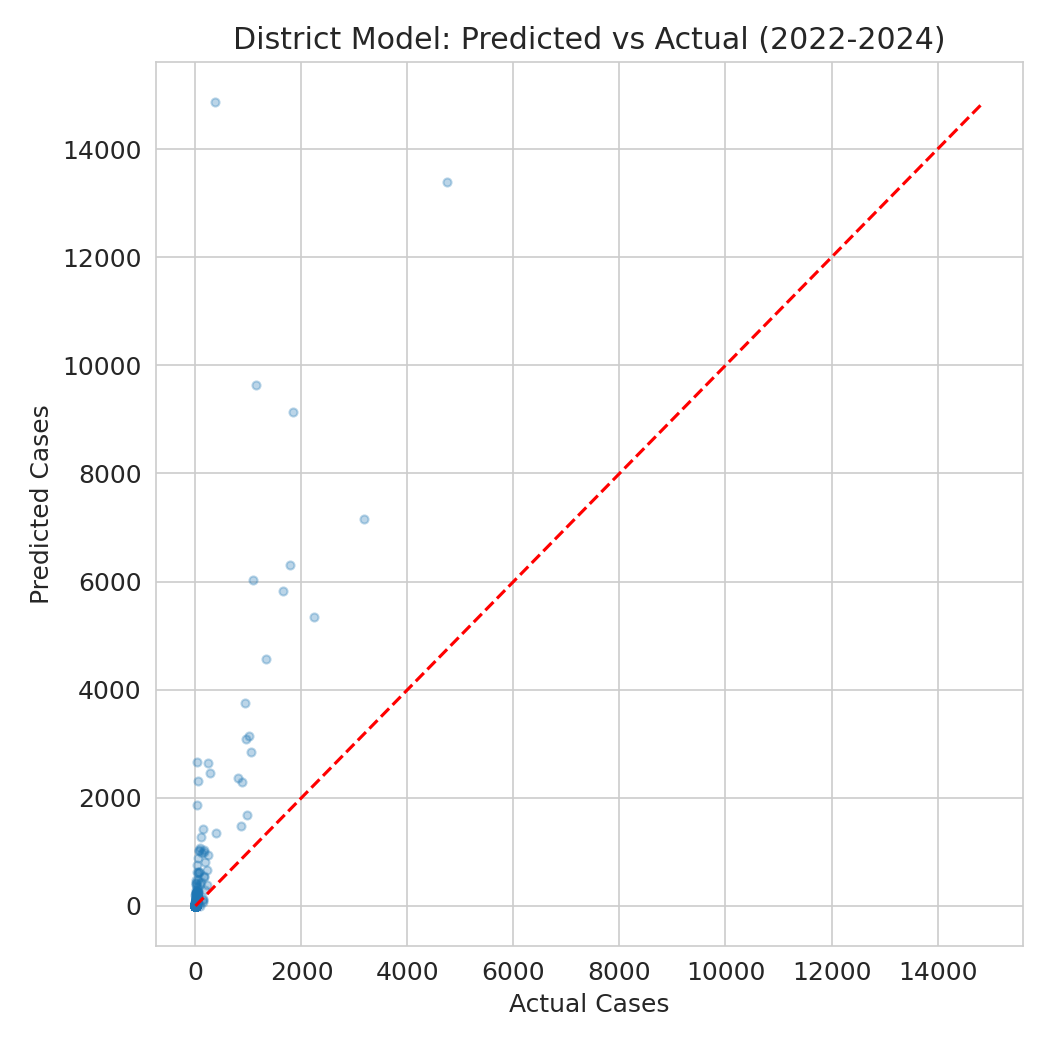

Displaying chart_district_feature_importance.png:


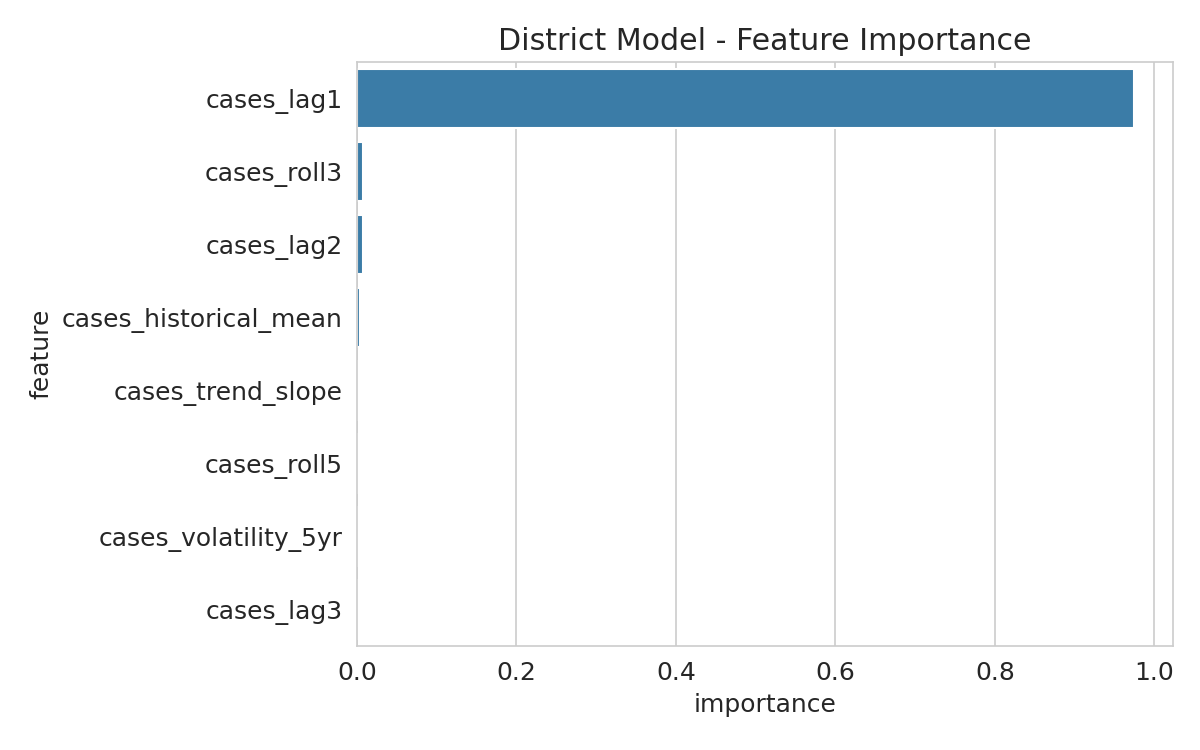

Displaying chart_state_cv_by_year.png:


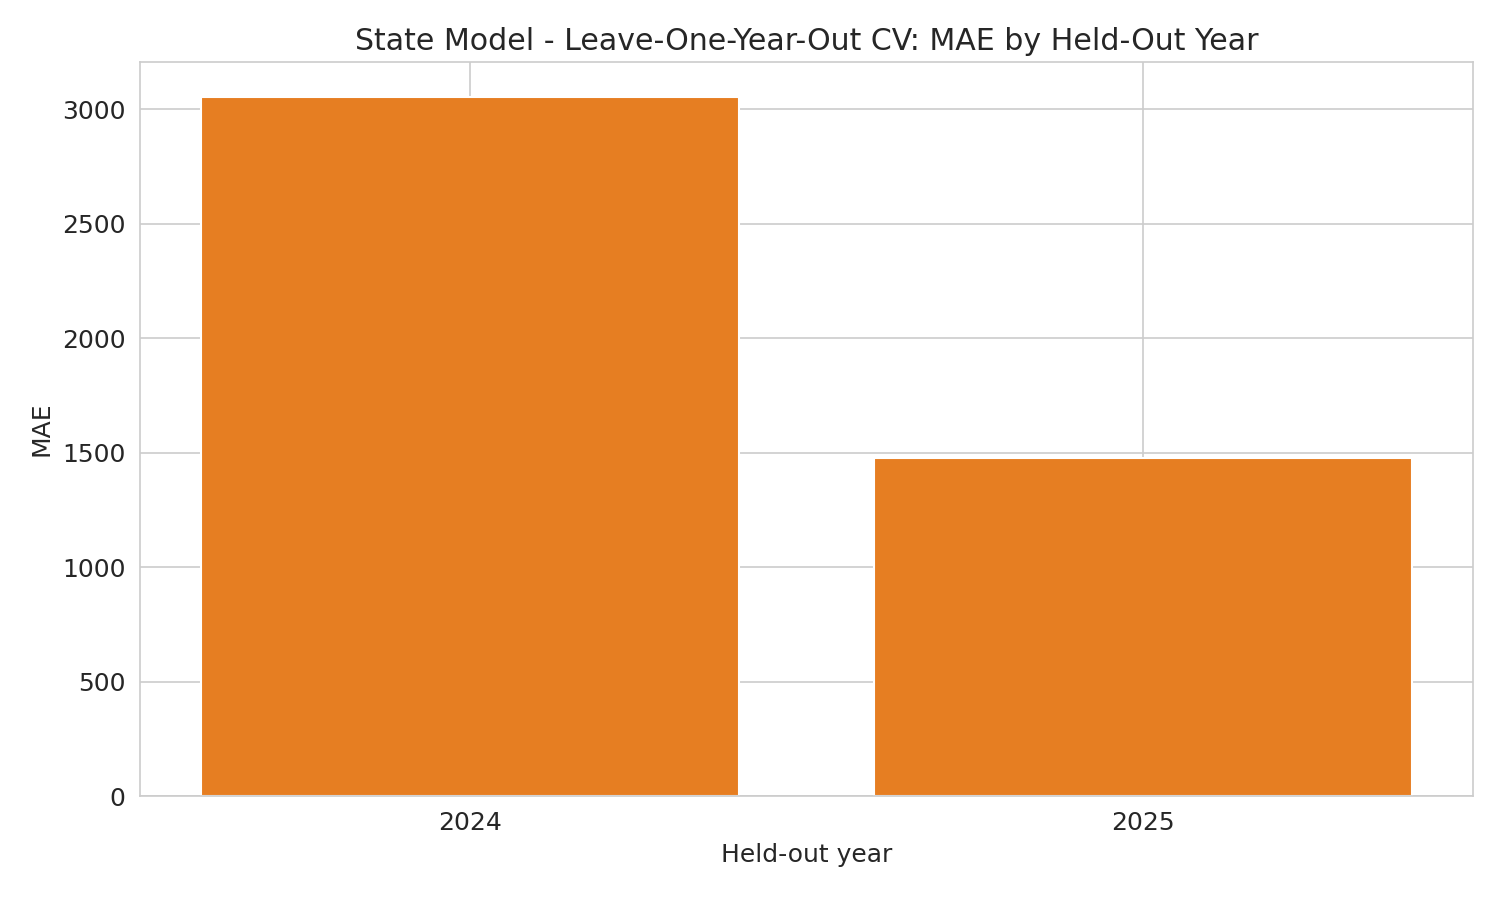

Displaying chart_state_feature_importance.png:


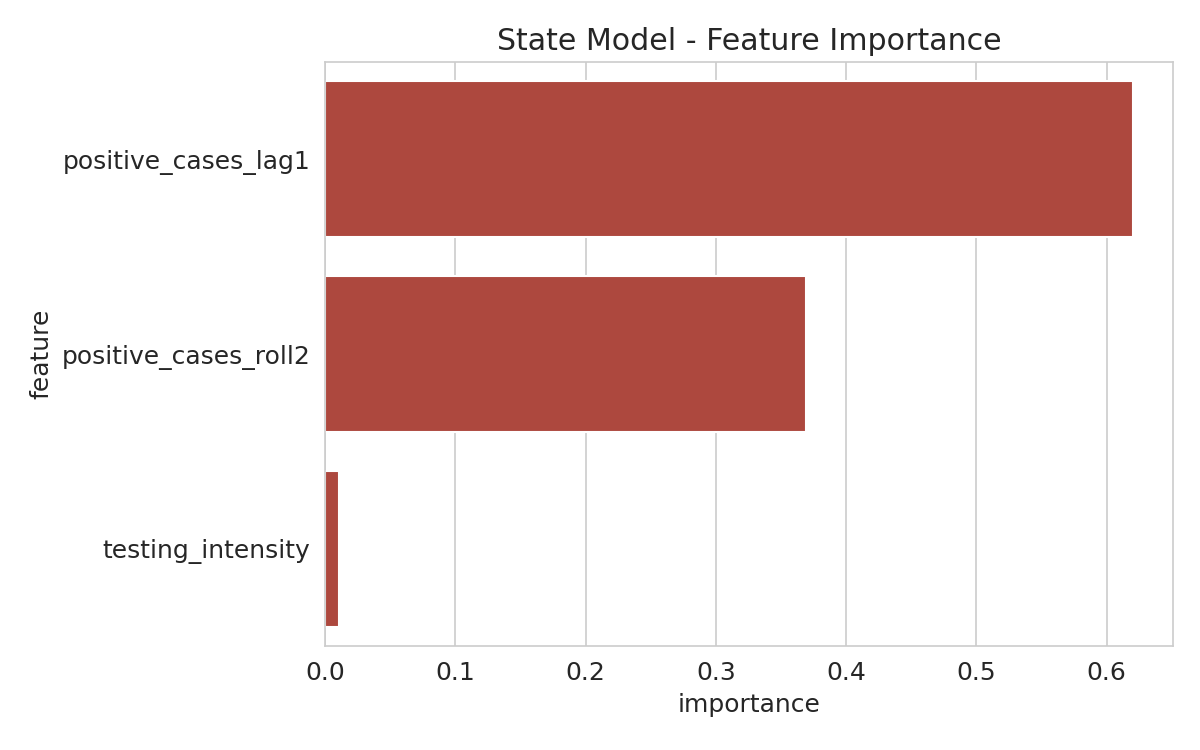

Displaying chart_combined_comparison.png:


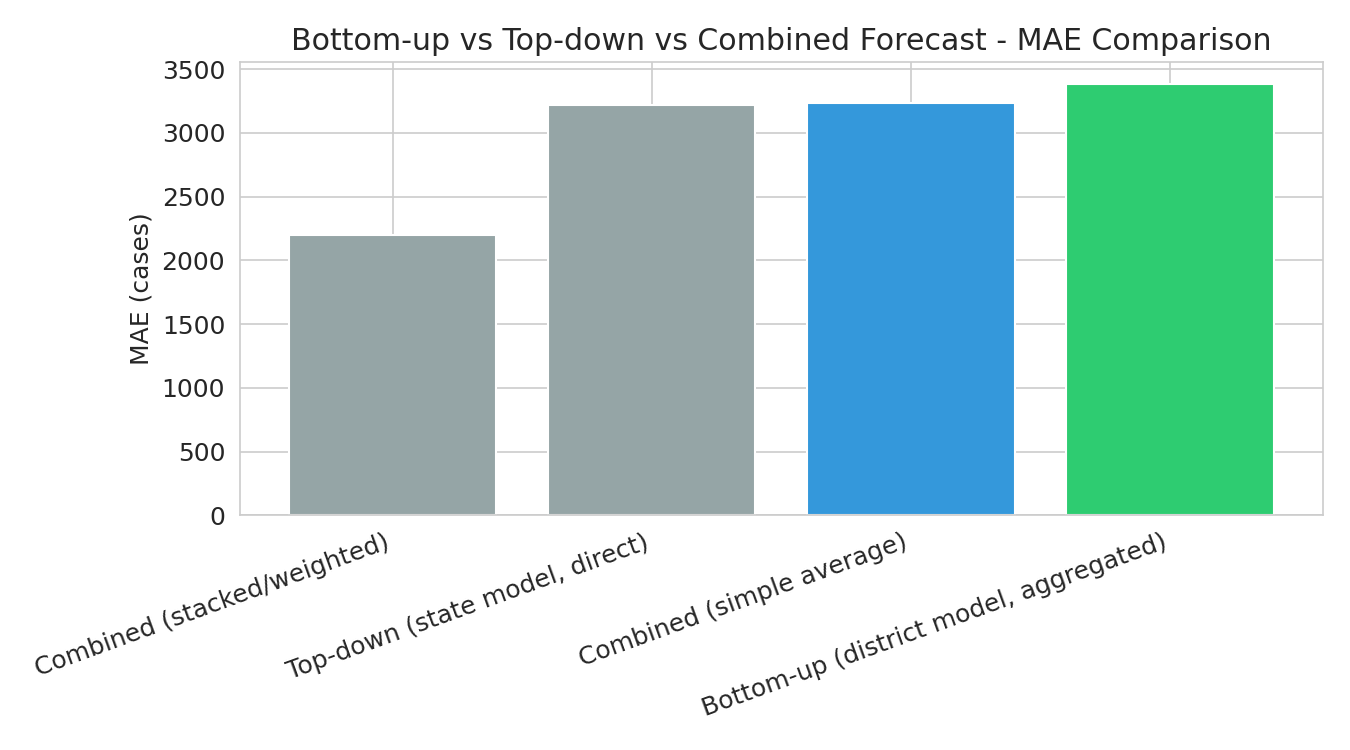

Displaying chart_combined_predicted_vs_actual.png:


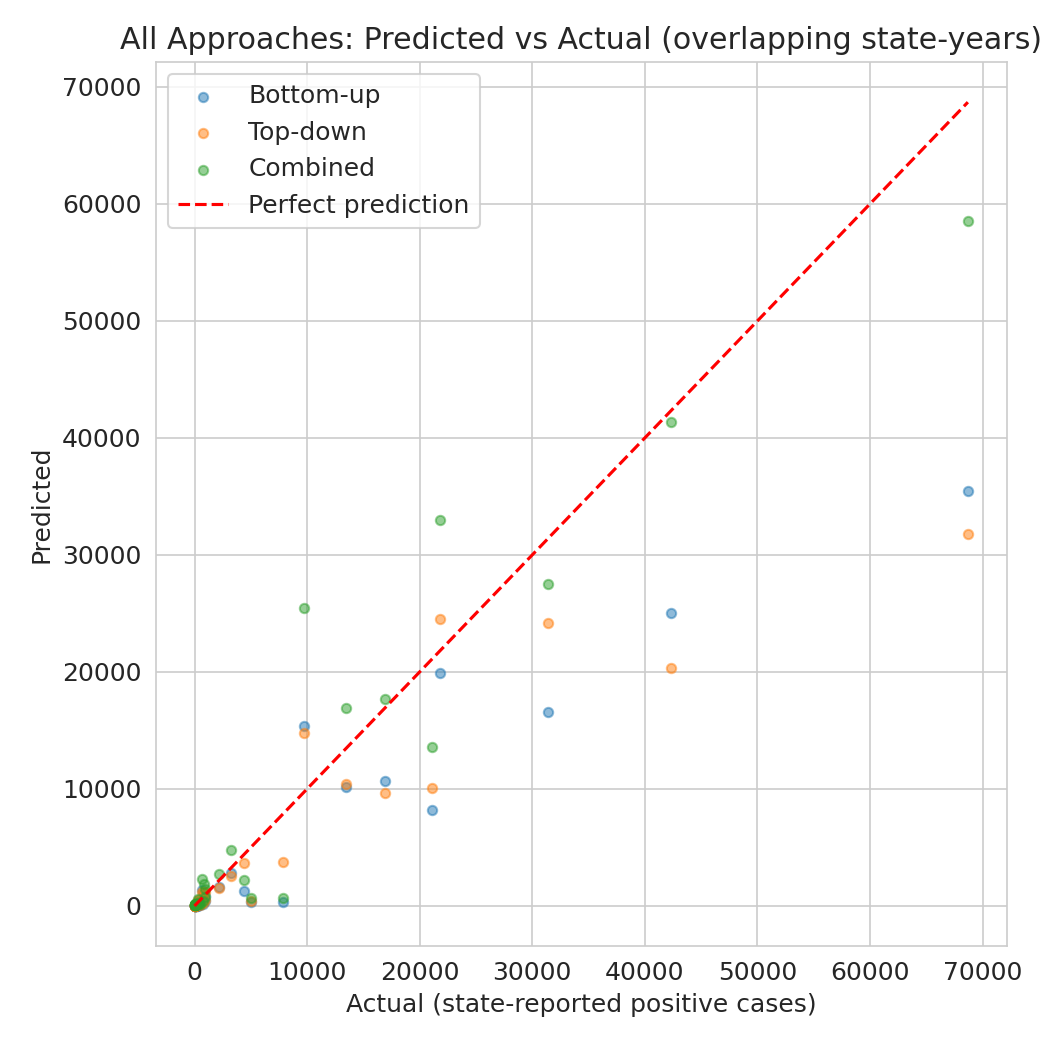

In [12]:
from IPython.display import Image, display
#  model analysis charts
chart_files=[
    "chart_district_predicted_vs_actual.png",
    "chart_district_feature_importance.png",
    "chart_state_cv_by_year.png",
    "chart_state_feature_importance.png",
    "chart_combined_comparison.png",
    "chart_combined_predicted_vs_actual.png"
]

for chart_file in chart_files:
    print(f"Displaying {chart_file}:")
    display(Image(filename=chart_file))